# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import scipy as spy
import copy
import math
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

---

# Dataset Reading and Inspection

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
data = pd.read_csv("/content/drive/MyDrive/CSE445/used_cars_data.csv")
print(data.columns)

Index(['S.No.', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type',
       'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats',
       'New_Price', 'Price'],
      dtype='object')


---

## Preview the dataset

In [5]:
# Preview the dataset
# View the first 5, last 5 and random 10 rows
print('First five rows', '--'*55)
display(data.head())

print('Last five rows', '--'*55)
display(data.tail())

print('Random ten rows', '--'*55)
np.random.seed(1)
display(data.sample(n=10))

First five rows --------------------------------------------------------------------------------------------------------------


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


Last five rows --------------------------------------------------------------------------------------------------------------


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
7248,7248,Volkswagen Vento Diesel Trendline,Hyderabad,2011,89411,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,NaN
7249,7249,Volkswagen Polo GT TSI,Mumbai,2015,59000,Petrol,Automatic,First,17.21 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7250,7250,Nissan Micra Diesel XV,Kolkata,2012,28000,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,NaN
7251,7251,Volkswagen Polo GT TSI,Pune,2013,52262,Petrol,Automatic,Third,17.2 kmpl,1197 CC,103.6 bhp,5.0,NaN,NaN
7252,7252,Mercedes-Benz E-Class 2009-2013 E 220 CDI Avan...,Kochi,2014,72443,Diesel,Automatic,First,10.0 kmpl,2148 CC,170 bhp,5.0,NaN,NaN


Random ten rows --------------------------------------------------------------------------------------------------------------


,S.No.,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
2397,2397,Ford EcoSport 1.5 Petrol Trend,Kolkata,2016,21460,Petrol,Manual,First,17.0 kmpl,1497 CC,121.36 bhp,5.0,9.47 Lakh,6.00
3777,3777,Maruti Wagon R VXI 1.2,Kochi,2015,49818,Petrol,Manual,First,21.5 kmpl,1197 CC,81.80 bhp,5.0,5.44 Lakh,4.11
4425,4425,Ford Endeavour 4x2 XLT,Hyderabad,2007,130000,Diesel,Manual,First,13.1 kmpl,2499 CC,141 bhp,7.0,NaN,6.00
3661,3661,Mercedes-Benz E-Class E250 CDI Avantgrade,Coimbatore,2016,39753,Diesel,Automatic,First,13.0 kmpl,2143 CC,201.1 bhp,5.0,NaN,35.28
4514,4514,Hyundai Xcent 1.2 Kappa AT SX Option,Kochi,2016,45560,Petrol,Automatic,First,16.9 kmpl,1197 CC,82 bhp,5.0,NaN,6.34
599,599,Toyota Innova Crysta 2.8 ZX AT,Coimbatore,2019,40674,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,7.0,28.05 Lakh,24.82
186,186,Mercedes-Benz E-Class E250 CDI Avantgrade,Bangalore,2014,37382,Diesel,Automatic,First,13.0 kmpl,2143 CC,201.1 bhp,5.0,NaN,32.00
305,305,Audi A6 2011-2015 2.0 TDI Premium Plus,Kochi,2014,61726,Diesel,Automatic,First,17.68 kmpl,1968 CC,174.33 bhp,5.0,NaN,20.77
4582,4582,Hyundai i20 1.2 Magna,Kolkata,2011,36000,Petrol,Manual,First,18.5 kmpl,1197 CC,80 bhp,5.0,NaN,2.50
5434,5434,Honda WR-V Edge Edition i-VTEC S,Kochi,2019,13913,Petrol,Manual,First,17.5 kmpl,1199 CC,88.7 bhp,5.0,9.36 Lakh,8.20


In [6]:
data.columns = [col.lower() for col in data.columns]
data.head(5)

,s.no.,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


## Get the shape of the dataset

In [7]:
shape = data.shape
n_rows = shape[0]
n_cols = shape[1]
print(f"The Dataframe consists of '{n_rows}' rows and '{n_cols}' columns")

The Dataframe consists of '7253' rows and '14' columns


## Data info

In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7253 entries, 0 to 7252
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   s.no.              7253 non-null   int64  
 1   name               7253 non-null   object 
 2   location           7253 non-null   object 
 3   year               7253 non-null   int64  
 4   kilometers_driven  7253 non-null   int64  
 5   fuel_type          7253 non-null   object 
 6   transmission       7253 non-null   object 
 7   owner_type         7253 non-null   object 
 8   mileage            7251 non-null   object 
 9   engine             7207 non-null   object 
 10  power              7207 non-null   object 
 11  seats              7200 non-null   float64
 12  new_price          1006 non-null   object 
 13  price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 793.4+ KB


**Missing value summary function**

In [9]:
def missing_val_chk(data):
    """
    This function to checks for missing values
    and generates a summary.
    """
    if data.isnull().sum().any() == True:
        # Number of missing in each column
        missing_vals = pd.DataFrame(data.isnull().sum().sort_values(
            ascending=False)).rename(columns={0: '# missing'})

        # Create a percentage missing
        missing_vals['percent'] = ((missing_vals['# missing'] / len(data)) *
                                   100).round(decimals=3)

        # Remove rows with 0
        missing_vals = missing_vals[missing_vals['# missing'] != 0].dropna()

        # display missing value dataframe
        print("The missing values summary")
        display(missing_vals)
    else:
        print("There are NO missing values in the dataset")

In [10]:
#Applying the missing value summary function
missing_val_chk(data)

The missing values summary


,# missing,percent
new_price,6247,86.130
price,1234,17.014
seats,53,0.731
engine,46,0.634
power,46,0.634
mileage,2,0.028


**Numerical type Summary**

In [11]:
# Five point summary of all numerical type variables in the dataset
data.describe().T

,count,mean,std,min,25%,50%,75%,max
s.no.,7253.0,3626.000000,2093.905084,0.00,1813.0,3626.00,5439.00,7252.0
year,7253.0,2013.365366,3.254421,1996.00,2011.0,2014.00,2016.00,2019.0
kilometers_driven,7253.0,58699.063146,84427.720583,171.00,34000.0,53416.00,73000.00,6500000.0
seats,7200.0,5.279722,0.811660,0.00,5.0,5.00,5.00,10.0
price,6019.0,9.479468,11.187917,0.44,3.5,5.64,9.95,160.0


**Categorical type Summary**

In [12]:
data.describe(include=['object']).T

,count,unique,top,freq
name,7253,2041,Mahindra XUV500 W8 2WD,55
location,7253,11,Mumbai,949
fuel_type,7253,5,Diesel,3852
transmission,7253,2,Manual,5204
owner_type,7253,4,First,5952
mileage,7251,450,17.0 kmpl,207
engine,7207,150,1197 CC,732
power,7207,386,74 bhp,280
new_price,1006,625,63.71 Lakh,6


# Feature Engineering

## `s.no.` column

In [13]:
data.drop(columns="s.no.",inplace=True)

In [14]:
data.head(10)

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74
5,Hyundai EON LPG Era Plus Option,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,NaN,2.35
6,Nissan Micra Diesel XV,Jaipur,2013,86999,Diesel,Manual,First,23.08 kmpl,1461 CC,63.1 bhp,5.0,NaN,3.50
7,Toyota Innova Crysta 2.8 GX AT 8S,Mumbai,2016,36000,Diesel,Automatic,First,11.36 kmpl,2755 CC,171.5 bhp,8.0,21 Lakh,17.50
8,Volkswagen Vento Diesel Comfortline,Pune,2013,64430,Diesel,Manual,First,20.54 kmpl,1598 CC,103.6 bhp,5.0,NaN,5.20
9,Tata Indica Vista Quadrajet LS,Chennai,2012,65932,Diesel,Manual,Second,22.3 kmpl,1248 CC,74 bhp,5.0,NaN,1.95


## `name` column

In [15]:
# The name will be split by the " " separator
# The first term will be assigned to the car_make
data["car_make"] = data.name.str.split(' ').str[0].str.upper()

# The second term will be assigned to the car_model
data["car_model"] = data.name.str.split(' ').str[1].str.upper()

# The third and remaining term will be joined using " " and assigned to the car_spec
data["car_spec"] = data.name.apply(lambda x: str.upper(" ".join(x.split(" ")[2:])))

In [16]:
data.head(5)

,name,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price,car_make,car_model,car_spec
0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG
1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50,HYUNDAI,CRETA,1.6 CRDI SX OPTION
2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50,HONDA,JAZZ,V
3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00,MARUTI,ERTIGA,VDI
4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74,AUDI,A4,NEW 2.0 TDI MULTITRONIC


Let's drop the name column

In [17]:
data.drop(columns = 'name', inplace=True)

Since the 'year' column represents the year of manufacture, let's get the age of the car by subtracting it from the year the survey was done.  
We shall use **2019** for the 2018-2019 period

Since we have seen that `year` datatype is **int64** we will need to converted to *datetime*.

## `year` column

In [18]:
data["car_age"]=2019-data.year

Let's check the first row in the dataframe to verify the additional of the `car_age` column

In [19]:
data.head(1)

,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price,car_make,car_model,car_spec,car_age
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9


 car age counts

In [20]:
data.car_age.value_counts()

,count
car_age,
4,929
5,925
3,886
6,791
2,709
7,690
8,579
9,407
1,361


---

## `mileage` column

 splitting the `mileage` column into `mileage_no` and `mileage_unit`
This will enable further analysis in car data.

In [21]:
# The mileage will be split by the " " separator
# The first term will be assigned to the mileage_no
data["mileage_no"] = data.mileage.str.split(' ').str[0]
# # The second term will be assigned to the mileage_unit
data["mileage_unit"] = data.mileage.str.split(' ').str[1]

Let's check the first row in the dataframe to verify the additional of the car columns

In [22]:
data.head(1)

,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price,car_make,car_model,car_spec,car_age,mileage_no,mileage_unit
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9,26.6,km/kg


Now let's see the number of unique `mileage_unit`

In [23]:
data.mileage_unit.nunique()

2

Now let's see the counts by `mileage_unit`

In [24]:
data.mileage_unit.value_counts()

,count
mileage_unit,
kmpl,7177
km/kg,74


Let's explore the **km/kg** mileage unit

In [25]:
data[data.mileage_unit=='km/kg']

,location,year,kilometers_driven,fuel_type,transmission,owner_type,mileage,engine,power,seats,new_price,price,car_make,car_model,car_spec,car_age,mileage_no,mileage_unit
0,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9,26.6,km/kg
5,Hyderabad,2012,75000,LPG,Manual,First,21.1 km/kg,814 CC,55.2 bhp,5.0,NaN,2.35,HYUNDAI,EON,LPG ERA PLUS OPTION,7,21.1,km/kg
127,Pune,2013,89900,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,3.25,MARUTI,WAGON,R LXI CNG,6,26.6,km/kg
328,Pune,2008,42496,CNG,Manual,First,26.3 km/kg,998 CC,67.1 bhp,5.0,NaN,1.40,MARUTI,ZEN,ESTILO LXI GREEN (CNG),11,26.3,km/kg
440,Kochi,2017,31841,CNG,Manual,First,15.1 km/kg,1196 CC,73 bhp,5.0,NaN,4.70,MARUTI,EECO,5 STR WITH AC PLUS HTR CNG,2,15.1,km/kg
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6538,Kochi,2015,47490,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN,NaN,MARUTI,ALTO,K10 LXI CNG,4,32.26,km/kg
6788,Delhi,2017,33000,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,4.66 Lakh,NaN,MARUTI,ALTO,K10 LXI CNG OPTIONAL,2,32.26,km/kg
6918,Jaipur,2010,40000,LPG,Manual,Second,13.2 km/kg,1495 CC,93.7 bhp,5.0,NaN,NaN,HYUNDAI,ACCENT,EXECUTIVE LPG,9,13.2,km/kg
6926,Mumbai,2017,15500,CNG,Manual,First,15.1 km/kg,1196 CC,73 bhp,5.0,NaN,NaN,MARUTI,EECO,5 STR WITH AC PLUS HTR CNG,2,15.1,km/kg


Let's explore the fuel types for km/kg mileage unit

In [26]:
data[data.mileage_unit=='km/kg'].fuel_type.value_counts()

,count
fuel_type,
CNG,62
LPG,12


Let's explore the transmissions for km/kg mileage unit

In [27]:
data[data.mileage_unit=='km/kg'].transmission.value_counts()

,count
transmission,
Manual,74


 dropping the **mileage** column

In [28]:
data.drop(columns='mileage',inplace=True)

For consistency, lets rename **mileage_no** to **mileage**

In [29]:
data = data.rename(columns={'mileage_no': 'mileage'})

Based on the string operations above the **mileage** column may still be a string.  
Let's convert to a float.

In [30]:
if data.mileage.dtypes != np.number:
    # This will convert all numeric strings to float.
    # If a value is non numeric it will set to NaN
    data['mileage'] = pd.to_numeric(data.mileage, errors='coerce')

---

## `engine` column

Let's split the `engine` column into `engine_disp` and `eng_disp_unit`
This will enable further analysis in car data.

In [31]:
# The engine will be split by the " " separator
# The first term will be assigned to the engine_disp
data["engine_disp"] = data.engine.str.split(' ').str[0]
# The second term will be assigned to the eng_disp_unit
data["eng_disp_unit"] = data.engine.str.split(' ').str[1]

Let's check the first row in the dataframe to verify the additional of the car columns

In [32]:
data.head(1)

,location,year,kilometers_driven,fuel_type,transmission,owner_type,engine,power,seats,new_price,price,car_make,car_model,car_spec,car_age,mileage,mileage_unit,engine_disp,eng_disp_unit
0,Mumbai,2010,72000,CNG,Manual,First,998 CC,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9,26.6,km/kg,998,CC


Now let's see the number of unique `eng_disp_unit`

In [33]:
data.eng_disp_unit.nunique()

1

Since there is only type of unit in the eng_disp_unit, this would not add significant value to the analysis.  
Let's drop the `eng_disp_unit` column

In [34]:
data.drop(columns = 'eng_disp_unit', inplace=True)

Since we dont need the initial `engine` column anymore, let's drop the `engine` column

In [35]:
data.drop(columns='engine',inplace=True)

For consistency, let's rename `engine_disp` to `engine`

In [36]:
data = data.rename(columns={'engine_disp': 'engine'})

Based on the string operations above the **engine** column may still be a string.  
Let's convert to a float.

In [37]:
if data.engine.dtypes != np.number:
    # This will convert all numeric strings to float.
    # If a value is non numeric it will set to NaN
    data['engine'] = pd.to_numeric(data.engine, errors='coerce')

---

## `power` column

Let's split the `power` column into `power_val` and `power_unit`.
This will enable further analysis in car data.

In [38]:
# The engine will be split by the " " separator
# The first term will be assigned to the engine_disp
data["power_val"] = data.power.str.split(' ').str[0]
# The second term will be assigned to the eng_disp_unit
data["power_unit"] = data.power.str.split(' ').str[1]

Let's check the first row in the dataframe to verify the additional of the car columns

In [39]:
data.head(1)

,location,year,kilometers_driven,fuel_type,transmission,owner_type,power,seats,new_price,price,car_make,car_model,car_spec,car_age,mileage,mileage_unit,engine,power_val,power_unit
0,Mumbai,2010,72000,CNG,Manual,First,58.16 bhp,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9,26.6,km/kg,998.0,58.16,bhp


**Now let's see the number of unique power_unit**

In [40]:
data.power_unit.nunique()

1

Since there is only type of unit in the power_unit.  
**Let's drop the power_unit column**

In [41]:
data.drop(columns='power_unit', inplace=True)

Since we dont need the initial **power** column anymore, let's drop the **power** column

In [42]:
data.drop(columns='power', inplace=True)

For consistency, let's rename **power_val** to **power**

In [43]:
data = data.rename(columns={'power_val': 'power'})

Based on the string operations above the **power** column may still be a string.  
Let's convert to a float.

In [44]:
if data.power.dtypes != np.number:
    # This will convert all numeric strings to float.
    # If a value is non numeric it will set to NaN
    data['power'] = pd.to_numeric(data.power, errors='coerce')

---

## `new_price` column

From above we have seen that the `new_price` contains missing values as well strings with cost in Lakh

**Now let's see the number of different strings for new_price**

In [45]:
data.new_price.nunique()

625

Now let's see the counts by **new_price** to see if there are similar strings

In [46]:
data.new_price.value_counts()

,count
new_price,
63.71 Lakh,6
95.13 Lakh,6
4.78 Lakh,6
33.36 Lakh,6
44.28 Lakh,5
...,...
6.83 Lakh,1
9.09 Lakh,1
7.17 Lakh,1


**Observation:**
* The majority of the new_price strings contain "Lakh" while there is an instance of "Cr"

Let's split the **new_price** column into **new_price_no** and **new_price_unit**.
This will enable further analysis in car data.

In [47]:
# The new_price will be split by the " " separator
# The first term will be assigned to the new_price_no
data["new_price_no"] = data.new_price.str.split(' ').str[0]
# The second term will be assigned to the new_price_unit
data["new_price_unit"] = data.new_price.str.split(' ').str[1]

Let's check the first row in the dataframe to verify the additional of the car columns

In [48]:
data.head(1)

,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,new_price,price,car_make,car_model,car_spec,car_age,mileage,mileage_unit,engine,power,new_price_no,new_price_unit
0,Mumbai,2010,72000,CNG,Manual,First,5.0,NaN,1.75,MARUTI,WAGON,R LXI CNG,9,26.6,km/kg,998.0,58.16,NaN,NaN


**Now let's see the number of different strings for new_price_unit**

In [49]:
data.new_price_unit.nunique()

2

**Now let's see the counts by new_price_unit to see if there are similar strings**

In [50]:
data.new_price_unit.value_counts()

,count
new_price_unit,
Lakh,986
Cr,20


There 2 different new_price_units.
Since the Data Dictionary has Lakh has the unit of price
Let's convert the instances of "Cr" to "Lakh"
**new_price_no** based on the following:
* 1 Cr = 100 Lakh

Convert `new_price_no` from *Cr INR* to *Lakh INR*. Then drop the `new_price_unit` column

In [51]:
# Convert to a string to numeric
if data.new_price_no.dtypes != np.number:
    # This will convert all numeric strings to float.
    # If a value is non numeric it will set to NaN
    data['new_price_no'] = pd.to_numeric(data.new_price_no, errors='coerce')

# Conversion factor
Cr_conv = 100

# Multiplier function to convert instance of new_price_no in Cr to Lakh
data.loc[data['new_price_unit'] == 'Cr', ['new_price_no']] *= Cr_conv

# Drop 'new_price_unit' column
data = data.drop(columns='new_price_unit')

Since we dont need the initial `new_price` column anymore, let's drop the `new_price` column

In [52]:
data.drop(columns='new_price', inplace=True)

For consistency, let's rename **new_price_no** to **new_price**

In [53]:
data = data.rename(columns={'new_price_no': 'new_price'})

---

## Check for duplicated rows

Let's check if there are any duplicated rows in the dataset

**Duplicate row check function**

In [54]:
def df_duplicate_removal(data):
    """
    This function checks if there are any duplicated rows in the dataframe.
    If any, it displays the rows, keep the first occurence and drops the
    duplicates.

    The new dataframe shape is calculated and returned
    """
    # Check if duplicated rows exist
    if any(data.duplicated() == True):
        print("The following is/are the duplicated row(s) in the dataframe")
        # Displays the duplicated row(s)
        display(data[data.duplicated() == True])
        # Drops the duplicates inplace while keeping the first occurence
        data.drop_duplicates(keep="first", inplace=True)

        # Check and returns the shape of the new dataframe
        new_df_shape = data.shape
        n_rows = new_df_shape[0]
        n_cols = new_df_shape[1]
        print(
            f"The new dataframe  consists of '{n_rows}' rows and '{n_cols}' columns")
    else:
        print("There is/are no duplicated row(s) in the dataframe")

In [55]:
df_duplicate_removal(data)

The following is/are the duplicated row(s) in the dataframe


,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,car_make,car_model,car_spec,car_age,mileage,mileage_unit,engine,power,new_price
4781,Hyderabad,2007,52195,Petrol,Manual,First,5.0,1.75,MARUTI,ALTO,LXI,12,19.7,kmpl,796.0,46.3,NaN
6582,Mumbai,2010,52000,Petrol,Manual,First,5.0,NaN,HONDA,CITY,1.5 E MT,9,17.0,kmpl,1497.0,118.0,NaN
7078,Kolkata,2017,13000,Diesel,Manual,First,5.0,NaN,HONDA,CITY,I DTEC SV,2,26.0,kmpl,1498.0,98.6,NaN


The new dataframe  consists of '7250' rows and '17' columns


---

## Data type conversion

Datatype conversion Converting pandas object types to category

In [56]:
# Convert variables with "object" type to "category" type
for i in data.columns:
    if data[i].dtypes == "object":
        data[i] = data[i].astype("category")

# Confirm if there no variables with "object" type
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7250 entries, 0 to 7252
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   location           7250 non-null   category
 1   year               7250 non-null   int64   
 2   kilometers_driven  7250 non-null   int64   
 3   fuel_type          7250 non-null   category
 4   transmission       7250 non-null   category
 5   owner_type         7250 non-null   category
 6   seats              7197 non-null   float64 
 7   price              6018 non-null   float64 
 8   car_make           7250 non-null   category
 9   car_model          7250 non-null   category
 10  car_spec           7250 non-null   category
 11  car_age            7250 non-null   int64   
 12  mileage            7248 non-null   float64 
 13  mileage_unit       7248 non-null   category
 14  engine             7204 non-null   float64 
 15  power              7075 non-null   float64 
 16  new_price  

---

## The 5 Point Summary

Let's run the 5 point descriptive statistics again

In [57]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
year,7250.0,2013.366207,3.253715,1996.00,2011.000,2014.00,2016.0000,2019.00
kilometers_driven,7250.0,58707.187586,84443.411557,171.00,34000.000,53469.50,73000.0000,6500000.00
seats,7197.0,5.279839,0.811809,0.00,5.000,5.00,5.0000,10.00
price,6018.0,9.480753,11.188403,0.44,3.500,5.64,9.9500,160.00
car_age,7250.0,5.633793,3.253715,0.00,3.000,5.00,8.0000,23.00
mileage,7248.0,18.140439,4.562150,0.00,15.170,18.16,21.1000,33.54
engine,7204.0,1616.720433,595.327259,72.00,1198.000,1493.00,1968.0000,5998.00
power,7075.0,112.775871,53.498756,34.20,75.000,94.00,138.1000,616.00
new_price,1006.0,22.779692,27.759344,3.91,7.885,11.57,26.0425,375.00


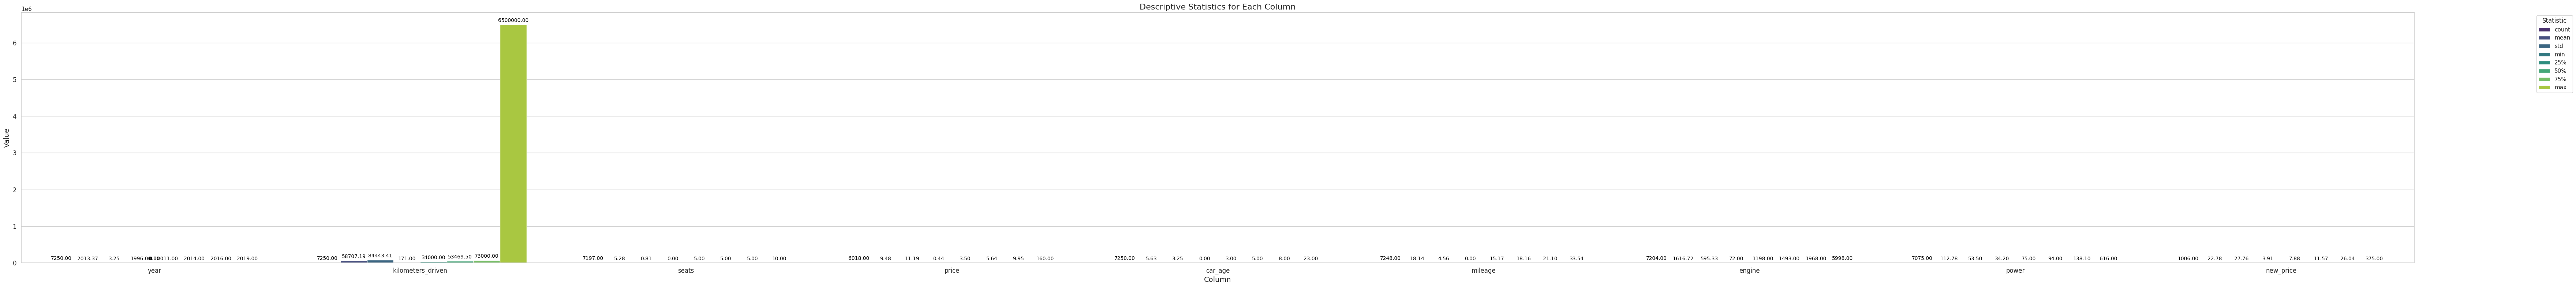

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get descriptive statistics and transpose
desc = data.describe().T

# Prepare data for plotting
desc_melted = desc.reset_index().melt(id_vars='index', var_name='Statistic', value_name='Value')
desc_melted.rename(columns={'index': 'Column'}, inplace=True)

# Plot setup
plt.figure(figsize=(70,8))
sns.set(style="whitegrid")

# Create a bar plot with hue for each statistic
sns.barplot(data=desc_melted, x="Column", y="Value", hue="Statistic", palette="viridis")

# Add title and labels
plt.title("Descriptive Statistics for Each Column", fontsize=16)
plt.xlabel("Column", fontsize=14)
plt.ylabel("Value", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Display values on the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='baseline', fontsize=10, color='black', xytext=(0, 5),
                       textcoords='offset points')

# Improve legend placement
plt.legend(title="Statistic", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Missing Value Treatment

## `mileage` column revisited

The `mileage` column has been observed to have a minimum of **0**.  
This implies that the manufacturer supplied mileage stats were not input into the dataset.  
Let's investigate further.

Lets check how many rows in the dataset has 0 in the mileage

In [59]:
print("There are {} rows with '0' in the mileage".format(len(data[data.mileage==0])))

There are 81 rows with '0' in the mileage


Lets view the rows with 0 mileage

In [60]:
data[data.mileage==0]

,location,year,kilometers_driven,fuel_type,transmission,owner_type,seats,price,car_make,car_model,car_spec,car_age,mileage,mileage_unit,engine,power,new_price
14,Pune,2012,85000,Diesel,Automatic,Second,5.0,17.50,LAND,ROVER,FREELANDER 2 TD4 SE,7,0.0,kmpl,2179.0,115.0,NaN
67,Coimbatore,2019,15369,Diesel,Automatic,First,5.0,35.67,MERCEDES-BENZ,C-CLASS,PROGRESSIVE C 220D,0,0.0,kmpl,1950.0,194.0,49.14
79,Hyderabad,2005,87591,Petrol,Manual,First,5.0,1.30,HYUNDAI,SANTRO,XING XL,14,0.0,kmpl,1086.0,NaN,NaN
194,Ahmedabad,2007,60006,Petrol,Manual,First,NaN,2.95,HONDA,CITY,1.5 GXI,12,0.0,kmpl,NaN,NaN,NaN
229,Bangalore,2015,70436,Diesel,Manual,First,NaN,3.60,FORD,FIGO,DIESEL,4,0.0,kmpl,1498.0,99.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6633,Kolkata,2016,27000,Diesel,Manual,First,NaN,NaN,MAHINDRA,TUV,300 P4,3,0.0,kmpl,NaN,NaN,NaN
6697,Jaipur,2007,85000,Petrol,Manual,Second,5.0,NaN,HYUNDAI,SANTRO,XING XL,12,0.0,kmpl,1086.0,NaN,NaN
6857,Mumbai,2011,87000,Diesel,Automatic,First,5.0,NaN,LAND,ROVER,FREELANDER 2 TD4 SE,8,0.0,kmpl,2179.0,115.0,NaN
6957,Kochi,2019,11574,Petrol,Manual,First,NaN,NaN,HONDA,JAZZ,2020 PETROL,0,0.0,kmpl,1199.0,88.7,NaN


There are cars of spanning a wide range of manufacture year and other specification.
Since this incorrect value of 0 will affect the analysis let replace 0 with NaN.

In [61]:
data.mileage.replace(to_replace=0, value= np.nan, inplace=True)

Let's check to see if mileage 0 values were changed

In [62]:
if any(data.mileage!=0):
    print("There are no 0 values in the mileage column")

There are no 0 values in the mileage column


## Missing Values

In [63]:
missing_val_chk(data)

The missing values summary


,# missing,percent
new_price,6244,86.124
price,1232,16.993
power,175,2.414
mileage,83,1.145
seats,53,0.731
engine,46,0.634
mileage_unit,2,0.028


---

## `new_price` column

In the `new_price` series, 86% of the values are missing. Since more than 60% of the values are missing, Let's drop the entire `new price` series.

In [64]:
data.drop(columns = 'new_price', inplace=True)

Let check the missing values in the dataframe

In [65]:
missing_val_chk(data)

The missing values summary


,# missing,percent
price,1232,16.993
power,175,2.414
mileage,83,1.145
seats,53,0.731
engine,46,0.634
mileage_unit,2,0.028


**There are no `new_price` missing values as the column has been dropped.**

---

## `price` column

We are trying to build a model to predict the used car prices, this indicates that the response variable is `price`.

Since the response variable is `price` we cannot simply impute values for missing `price` series.  
Therefore we shall drop all rows in the `price` column with NaN.

In [66]:
data.dropna(subset=['price'], inplace=True)

Let check the missing values in the dataframe

In [67]:
missing_val_chk(data)

The missing values summary


,# missing,percent
power,143,2.376
mileage,70,1.163
seats,42,0.698
engine,36,0.598
mileage_unit,2,0.033


**There are no missing values for the `price` series**

---

## Data imputation rationale

To begin let's combine the `car_make`and `car_model` and add it to the dataframe

In [68]:
data['car_name'] = data[['car_make', 'car_model']].apply(lambda x: ' '.join(x), axis=1)

---

## `power` column

Let's create a `car_power` dataframe by filtering all non-null `power` values and calculate the `mean power` values by the `car_name`.

In [69]:
car_power = data[data.power.notnull()].filter(["car_name", "power"])

From the car_power dataframe let's get the `mean power` by `car_name`

In [70]:
car_power = car_power.groupby("car_name").agg('mean')
car_power

,power
car_name,
AMBASSADOR CLASSIC,35.500000
AUDI A3,143.000000
AUDI A4,163.634416
AUDI A6,186.290000
AUDI A7,241.400000
...,...
VOLVO S60,185.857143
VOLVO S80,215.000000
VOLVO V40,150.000000


To impute the missing power values with the `mean power` by `car_name` we need to configure the `data` dataframe to be similiar to the `car_power` dataframe.   
We shall set the `data`  index to the `car_name`

In [71]:
data = data.set_index('car_name')

Let's used the `combine_first` function to update null elements with value in the same location.

In [72]:
data = data.combine_first(car_power)

Reset `data` index

In [73]:
data = data.reset_index()

Let check the missing values in the dataframe

In [74]:
missing_val_chk(data)

The missing values summary


,# missing,percent
mileage,70,1.163
seats,42,0.698
engine,36,0.598
power,11,0.183
mileage_unit,2,0.033


Let's investigate further to determine why there are still 11 missing `power` values.

In [75]:
data[data.power.isnull()]

,car_name,car_age,car_make,car_model,car_spec,engine,fuel_type,kilometers_driven,location,mileage,mileage_unit,owner_type,power,price,seats,transmission,year
660,FIAT PETRA,14,FIAT,PETRA,1.2 EL,1242.0,Petrol,120000,Pune,15.5,kmpl,Second,NaN,0.85,5.0,Manual,2005
666,FIAT SIENA,18,FIAT,SIENA,1.2 ELX,1242.0,Petrol,70000,Jaipur,NaN,kmpl,Third,NaN,0.55,5.0,Manual,2001
2820,MAHINDRA JEEP,10,MAHINDRA,JEEP,MM 550 PE,2498.0,Diesel,26000,Hyderabad,NaN,kmpl,First,NaN,6.99,6.0,Manual,2009
2821,MAHINDRA JEEP,17,MAHINDRA,JEEP,MM 540 DP,2112.0,Diesel,75000,Chennai,NaN,kmpl,First,NaN,1.70,6.0,Manual,2002
3076,MARUTI 1000,21,MARUTI,1000,AC,970.0,Petrol,104000,Hyderabad,15.0,kmpl,Second,NaN,0.85,5.0,Manual,1998
3562,MARUTI ESTILO,11,MARUTI,ESTILO,LXI,1061.0,Petrol,56000,Chennai,19.5,kmpl,Second,NaN,1.50,NaN,Manual,2008
3563,MARUTI ESTILO,9,MARUTI,ESTILO,LXI,1061.0,Petrol,40000,Kolkata,19.5,kmpl,Second,NaN,2.50,NaN,Manual,2010
3564,MARUTI ESTILO,11,MARUTI,ESTILO,LXI,1061.0,Petrol,51000,Chennai,19.5,kmpl,Second,NaN,1.75,NaN,Manual,2008
4756,PORSCHE CAYMAN,9,PORSCHE,CAYMAN,2009-2012 S,3436.0,Petrol,10000,Hyderabad,9.0,kmpl,First,NaN,40.00,2.0,Manual,2010
4757,PORSCHE CAYMAN,8,PORSCHE,CAYMAN,2009-2012 S TIPTRONIC,3436.0,Petrol,8000,Mumbai,9.0,kmpl,First,NaN,43.00,2.0,Automatic,2011


From the dataset, the `power` data is manufacturer supplied specification.  
These 11 cases highlight instances where unique cars dont have `power` data.  
For simplicity we shall impute the `mean power` in this analysis.

In [76]:
data.power.fillna(data.power.mean(), inplace=True)

Let check the missing values in the dataframe

In [77]:
missing_val_chk(data)

The missing values summary


,# missing,percent
mileage,70,1.163
seats,42,0.698
engine,36,0.598
mileage_unit,2,0.033


---

## `mileage` column

Let's create a `car_mileage` dataframe by filtering all non-null `mileage` values and calculate the `mean mileage` values by the `car_name`.

In [78]:
car_mileage = data[data.mileage.notnull()].filter(["car_name", "mileage"])

From the car_mileage dataframe let's get the `mean mileage` by `car_name`

In [79]:
car_mileage = car_mileage.groupby("car_name").agg('mean')
car_mileage

,mileage
car_name,
AMBASSADOR CLASSIC,12.800000
AUDI A3,20.380000
AUDI A4,16.400897
AUDI A6,16.581837
AUDI A7,14.400000
...,...
VOLVO S60,16.108571
VOLVO S80,14.550000
VOLVO V40,20.050000


To impute the missing mileage values with the `mean mileage` by `car_name` we need to configure the `data` dataframe to be similiar to the `car_mileage` dataframe.   
We shall set the `data`  index to the `car_name`

In [80]:
data = data.set_index('car_name')

Let's used the `combine_first` function to update null elements with value in the same location.

In [81]:
data = data.combine_first(car_mileage)

Reset `data` index

In [82]:
data = data.reset_index()

Let check the missing values in the dataframe

In [83]:
missing_val_chk(data)

The missing values summary


,# missing,percent
seats,42,0.698
engine,36,0.598
mileage,9,0.150
mileage_unit,2,0.033


Let's investigate further to determine why there are still 9 missing `mileage` values.

In [84]:
data[data.mileage.isnull()]

,car_name,car_age,car_make,car_model,car_spec,engine,fuel_type,kilometers_driven,location,mileage,mileage_unit,owner_type,power,price,seats,transmission,year
666,FIAT SIENA,18,FIAT,SIENA,1.2 ELX,1242.0,Petrol,70000,Jaipur,NaN,kmpl,Third,112.682838,0.55,5.0,Manual,2001
2819,MAHINDRA E,3,MAHINDRA,E,VERITO D4,72.0,Electric,50000,Chennai,NaN,NaN,First,41.000000,13.00,5.0,Automatic,2016
2820,MAHINDRA JEEP,10,MAHINDRA,JEEP,MM 550 PE,2498.0,Diesel,26000,Hyderabad,NaN,kmpl,First,112.682838,6.99,6.0,Manual,2009
2821,MAHINDRA JEEP,17,MAHINDRA,JEEP,MM 540 DP,2112.0,Diesel,75000,Chennai,NaN,kmpl,First,112.682838,1.70,6.0,Manual,2002
4306,MERCEDES-BENZ C-CLASS,0,MERCEDES-BENZ,C-CLASS,PROGRESSIVE C 220D,1950.0,Diesel,15369,Coimbatore,NaN,kmpl,First,194.000000,35.67,5.0,Automatic,2019
4307,MERCEDES-BENZ C-CLASS,1,MERCEDES-BENZ,C-CLASS,PROGRESSIVE C 220D,1950.0,Diesel,8682,Mumbai,NaN,kmpl,First,194.000000,39.50,5.0,Automatic,2018
4308,MERCEDES-BENZ C-CLASS,0,MERCEDES-BENZ,C-CLASS,PROGRESSIVE C 220D,1950.0,Diesel,4000,Ahmedabad,NaN,kmpl,First,194.000000,35.00,5.0,Automatic,2019
5084,SMART FORTWO,11,SMART,FORTWO,CDI AT,799.0,Diesel,103000,Pune,NaN,kmpl,Second,112.682838,3.00,2.0,Automatic,2008
5677,TOYOTA PRIUS,8,TOYOTA,PRIUS,2009-2016 Z4,1798.0,Electric,44000,Mumbai,NaN,NaN,First,73.000000,12.75,5.0,Automatic,2011


From the dataset, the `mileage` data is manufacturer supplied specification.  
These 9 cases highlight instances where unique cars dont have `mileage` data.  
For simplicity we shall impute the `mean mileage` in this analysis.

In [85]:
data.mileage.fillna(data.mileage.mean(), inplace=True)

Let check the missing values in the dataframe

In [86]:
missing_val_chk(data)

The missing values summary


,# missing,percent
seats,42,0.698
engine,36,0.598
mileage_unit,2,0.033


All the missing `mileage` values have been dealt with.

---

## `seats` column

Let's create a `car_seats` dataframe by filtering all non-null `seats` values and calculate the `median seats` values by the `car_name`.

In [87]:
car_seats = data[data.seats.notnull()].filter(["car_name", "seats"])

From the car_seats dataframe let's get the `median seats` by `car_name`

In [88]:
car_seats = car_seats.groupby("car_name").agg('median')
car_seats

,seats
car_name,
AMBASSADOR CLASSIC,5.0
AUDI A3,5.0
AUDI A4,5.0
AUDI A6,5.0
AUDI A7,5.0
...,...
VOLVO S60,5.0
VOLVO S80,5.0
VOLVO V40,5.0


To impute the missing seats values with the `median seats` by `car_name` we need to configure the `data` dataframe to be similiar to the `car_seats` dataframe.   
We shall set the `data`  index to the `car_name`

In [89]:
data= data.set_index('car_name')

Let's used the `combine_first` function to update null elements with value in the same location.

In [90]:
data = data.combine_first(car_seats)

Reset `data` index

In [91]:
data = data.reset_index()

Let check the missing values in the dataframe

In [92]:
missing_val_chk(data)

The missing values summary


,# missing,percent
engine,36,0.598
seats,3,0.050
mileage_unit,2,0.033


Let's investigate further to determine why there are still 3 missing `seats` values.

In [93]:
data[data.seats.isnull()]

,car_name,car_age,car_make,car_model,car_spec,engine,fuel_type,kilometers_driven,location,mileage,mileage_unit,owner_type,power,price,seats,transmission,year
3562,MARUTI ESTILO,11,MARUTI,ESTILO,LXI,1061.0,Petrol,56000,Chennai,19.5,kmpl,Second,112.682838,1.50,NaN,Manual,2008
3563,MARUTI ESTILO,9,MARUTI,ESTILO,LXI,1061.0,Petrol,40000,Kolkata,19.5,kmpl,Second,112.682838,2.50,NaN,Manual,2010
3564,MARUTI ESTILO,11,MARUTI,ESTILO,LXI,1061.0,Petrol,51000,Chennai,19.5,kmpl,Second,112.682838,1.75,NaN,Manual,2008


From above we can see that there are 3 cases where the `seats` values is missing.  
The MARUTI ESTILO is a unique vehicle in the dataset where there are no instances of `seats` being given.  
Let's assume this is a sedan and has the typical number of `seats` as any other car in the dataset.  
Therefore we shall impute the `median seats` for these 3 cases.

In [94]:
data.seats.fillna(data.seats.median(), inplace=True)

Let check the missing values in the dataframe

In [95]:
missing_val_chk(data)

The missing values summary


,# missing,percent
engine,36,0.598
mileage_unit,2,0.033


All the missing `seats` values have been dealt with.

---

## `engine` column

Let's create a `car_name` dataframe by filtering all non-null `engine` values and calculate the `mean engine` values by the `car_name`.

In [96]:
car_engine = data[data.engine.notnull()].filter(["car_name", "engine"])

From the car_engine dataframe let's get the `mean engine size` by `car_name`

In [97]:
car_engine = car_engine.groupby("car_name").agg('mean')
car_engine

,engine
car_name,
AMBASSADOR CLASSIC,1489.000000
AUDI A3,1968.000000
AUDI A4,2020.871795
AUDI A6,2189.857143
AUDI A7,2967.000000
...,...
VOLVO S60,2039.285714
VOLVO S80,2400.000000
VOLVO V40,1980.250000


To impute the missing engine values with the `mean engine size` by `car_name` we need to configure the `data` dataframe to be similiar to the `car_engine` dataframe.   
We shall set the `data`  index to the `car_name`

In [98]:
data = data.set_index('car_name')

Let's used the `combine_first` function to update null elements with value in the same location.

In [99]:
data = data.combine_first(car_engine)

Reset `data` index

In [100]:
data = data.reset_index()

Let check the missing values in the dataframe

In [101]:
missing_val_chk(data)

The missing values summary


,# missing,percent
mileage_unit,2,0.033


All the missing `engine` values have been dealt with.

---

## `mileage_unit` column

Let's check the rows where mileage_unit is NaN

In [102]:
data[data.mileage_unit.isnull()]

,car_name,car_age,car_make,car_model,car_spec,engine,fuel_type,kilometers_driven,location,mileage,mileage_unit,owner_type,power,price,seats,transmission,year
2819,MAHINDRA E,3,MAHINDRA,E,VERITO D4,72.0,Electric,50000,Chennai,18.317139,NaN,First,41.0,13.00,5.0,Automatic,2016
5677,TOYOTA PRIUS,8,TOYOTA,PRIUS,2009-2016 Z4,1798.0,Electric,44000,Mumbai,18.317139,NaN,First,73.0,12.75,5.0,Automatic,2011


We can see that the two rows are Electric powered cars.  
Let's check the dataframe to see if there are other Electric powered cars.

In [103]:
data[data.fuel_type=="Electric"]

,car_name,car_age,car_make,car_model,car_spec,engine,fuel_type,kilometers_driven,location,mileage,mileage_unit,owner_type,power,price,seats,transmission,year
2819,MAHINDRA E,3,MAHINDRA,E,VERITO D4,72.0,Electric,50000,Chennai,18.317139,NaN,First,41.0,13.00,5.0,Automatic,2016
5677,TOYOTA PRIUS,8,TOYOTA,PRIUS,2009-2016 Z4,1798.0,Electric,44000,Mumbai,18.317139,NaN,First,73.0,12.75,5.0,Automatic,2011


Since there are only 2 Electric powered cars in the dataset and they both are missing the `mileage_unit`, then let's drop  the rows where mileage_unit is `NaN`

In [104]:
data = data.dropna(subset=['mileage_unit'])

Let check the missing values in the dataframe

In [105]:
missing_val_chk(data)

There are NO missing values in the dataset


---

**The 5 Point Summary**

Let's run the 5 point descriptive statistics again

In [106]:
data.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
car_name,6016,213,MARUTI SWIFT,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_age,6016.0,NaN,NaN,NaN,5.640791,3.269211,0.0,3.0,5.0,8.0,21.0
car_make,6016,30,MARUTI,1210,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_model,6016,209,SWIFT,353,NaN,NaN,NaN,NaN,NaN,NaN,NaN
car_spec,6016,1703,VDI,110,NaN,NaN,NaN,NaN,NaN,NaN,NaN
engine,6016.0,NaN,NaN,NaN,1621.006295,600.658687,624.0,1198.0,1493.0,1984.0,5998.0
fuel_type,6016,4,Diesel,3205,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kilometers_driven,6016.0,NaN,NaN,NaN,58743.370346,91291.294238,171.0,34000.0,53000.0,73000.0,6500000.0
location,6016,11,Mumbai,789,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mileage,6016.0,NaN,NaN,NaN,18.317139,4.165363,6.4,15.3,18.16,21.1,33.54


**Observation:**
* **car_name** - Most popular car name is MARUTI SWIFT
* **fuel_type** - Most popular fuel_type is Diesel
* **location** - Most popular location is Mumbai
* **mileage_unit** - Most popular mileage unit is kmpl
* **owner_type** - Most popular owner_type is First.
* **trasmission** - Most popular trasmission is Manual
* **year**  - The dataset has cars manufactured from 1996 to 2019
* **car_age** - The mean and median car age are close.

---

# Univariate Analysis

## Numerical Variables (Plotting, Outlier Removal)

**List of numerical variables**

In [107]:
num_var= data.select_dtypes(include=np.number).columns.to_list()
print(num_var)

['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']


**Scatterplot of numerical variables**

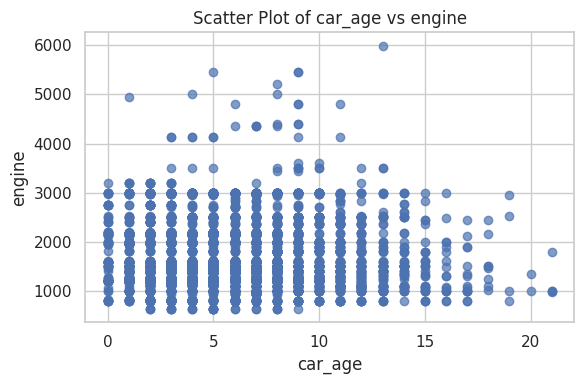

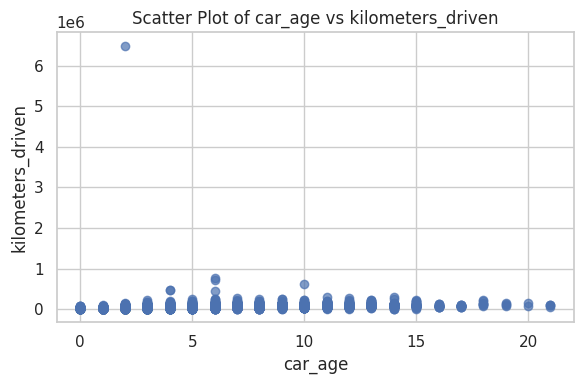

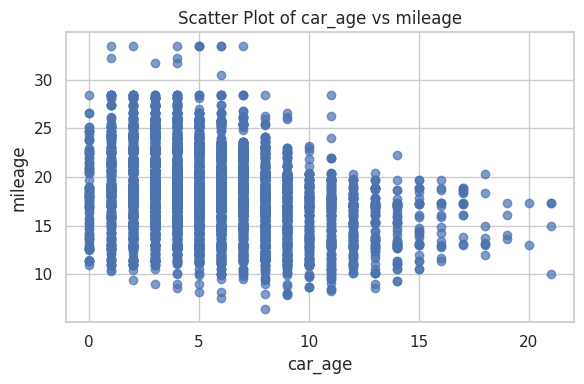

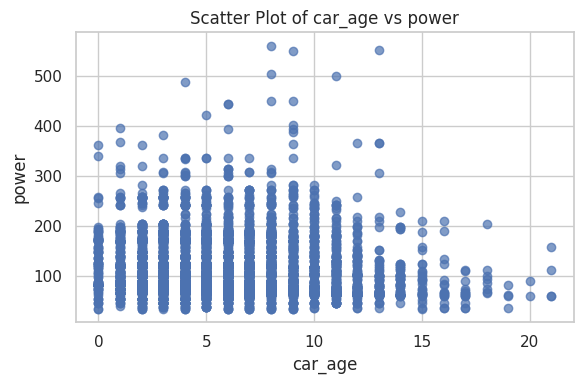

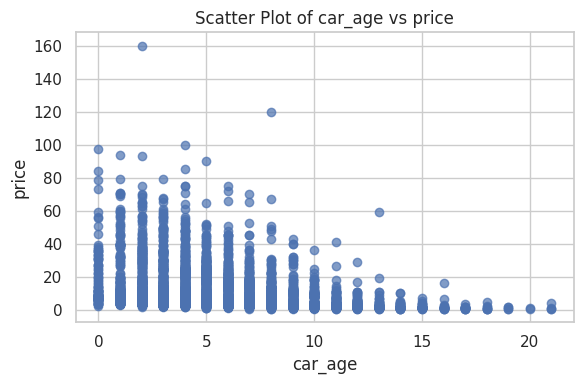

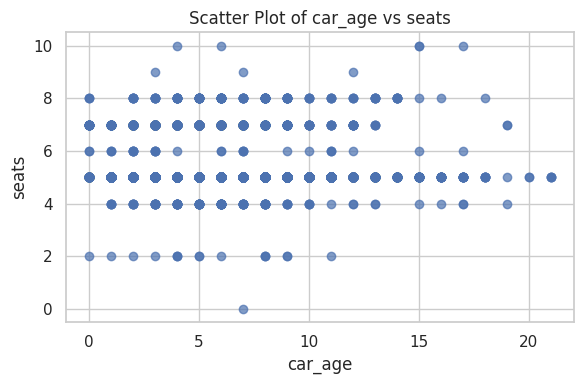

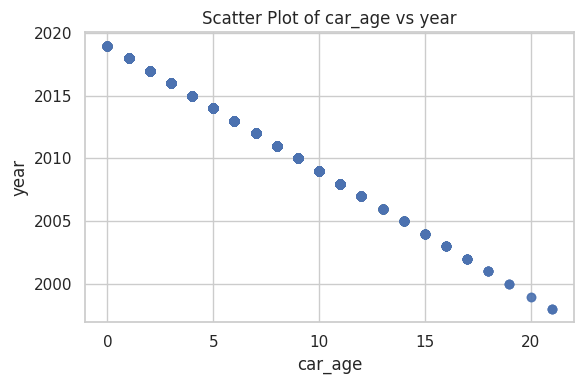

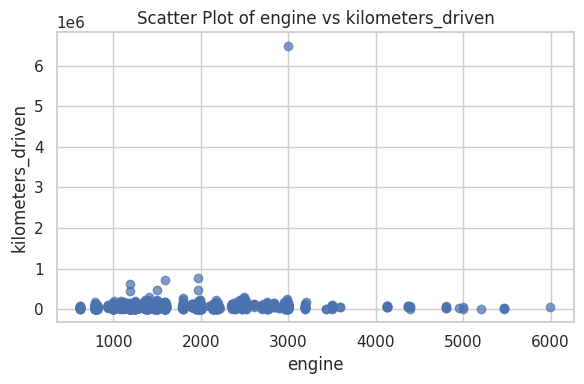

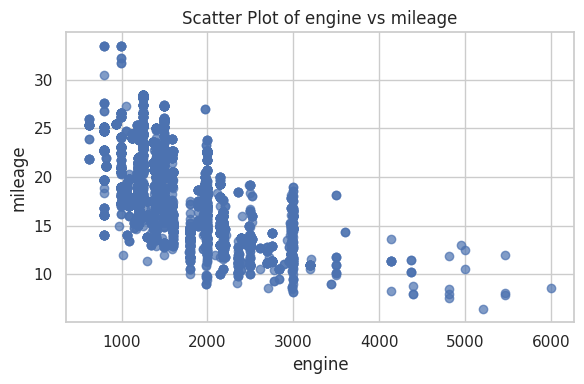

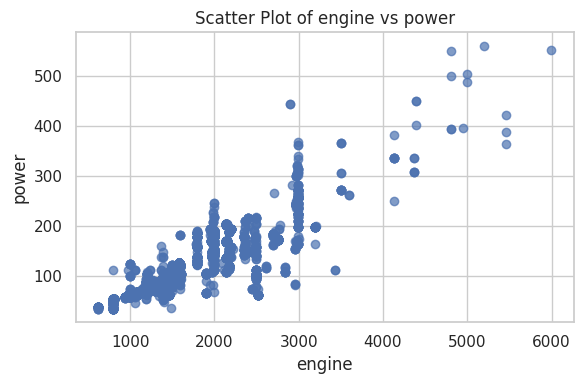

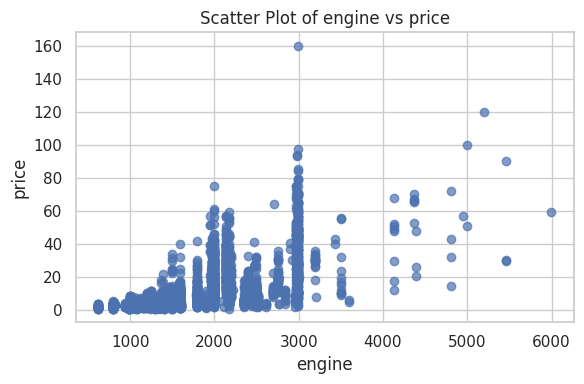

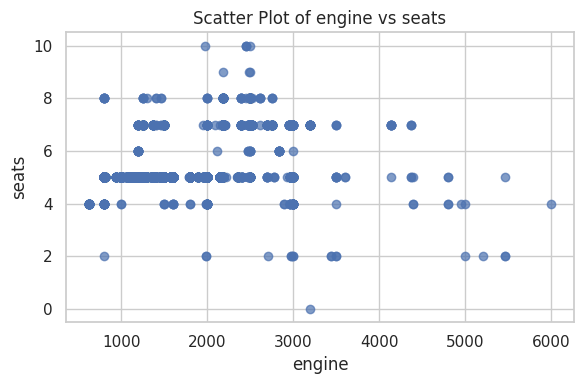

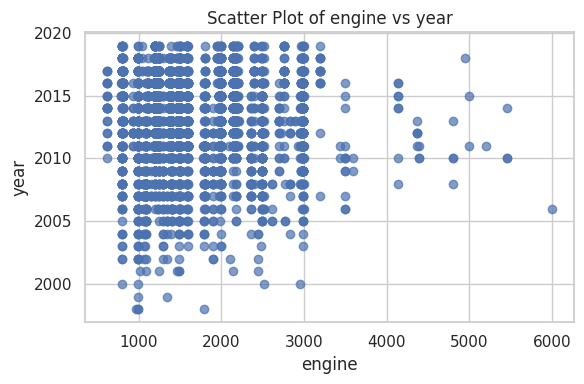

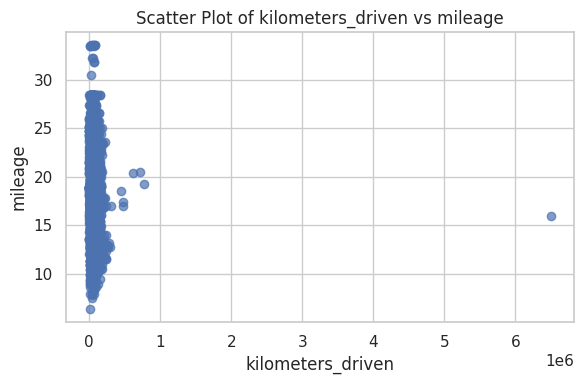

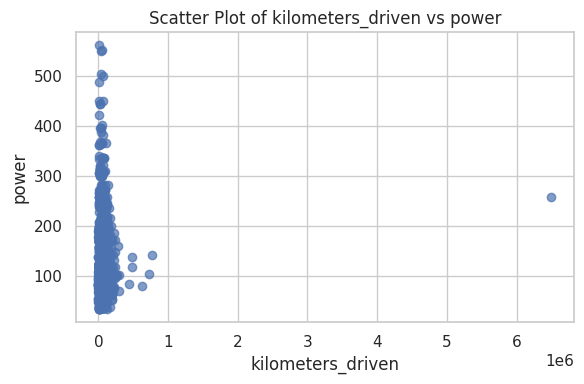

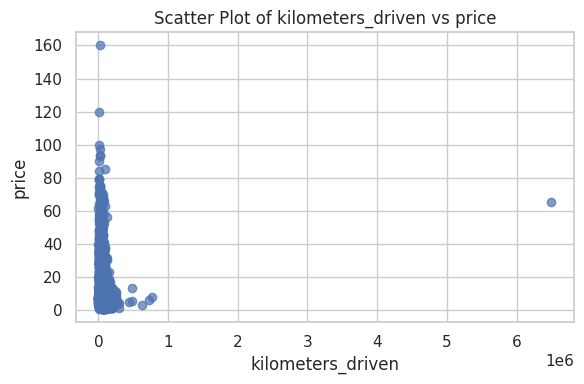

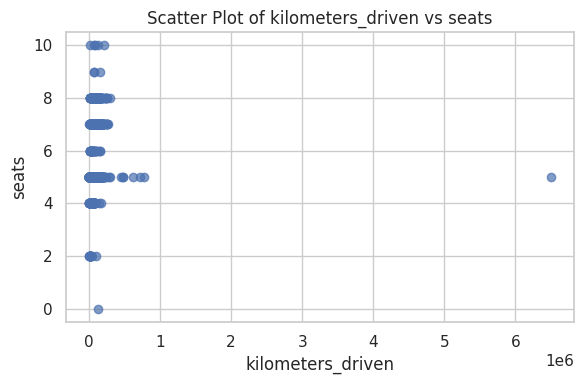

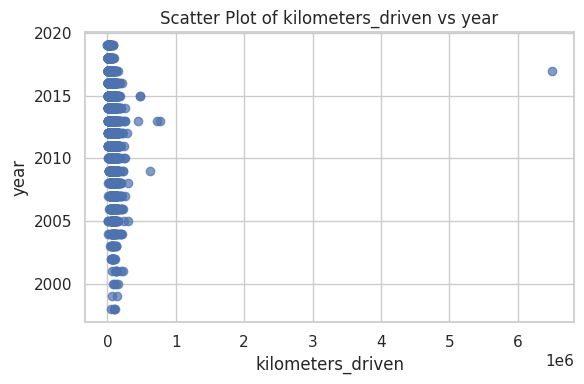

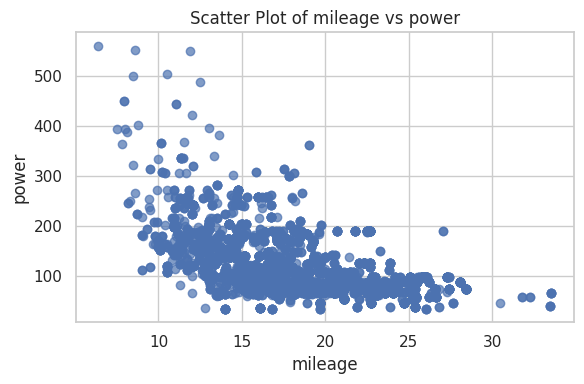

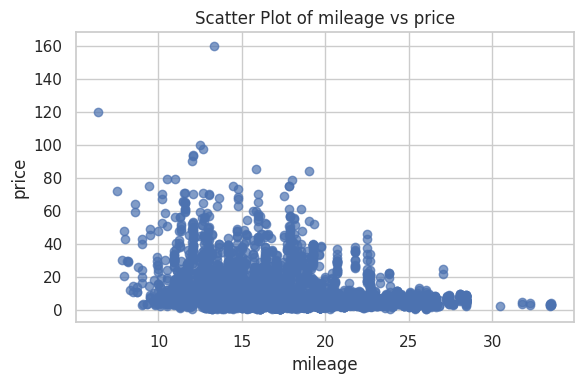

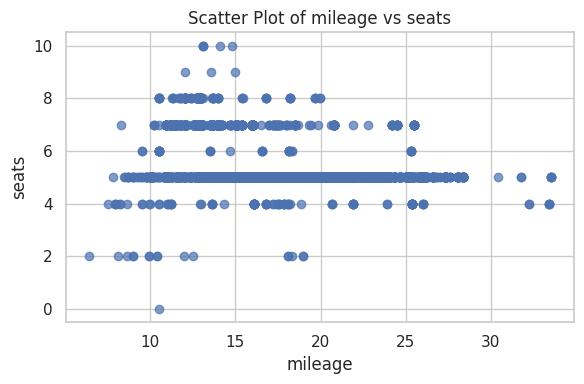

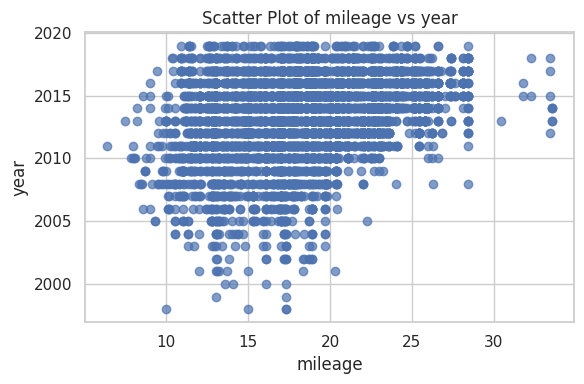

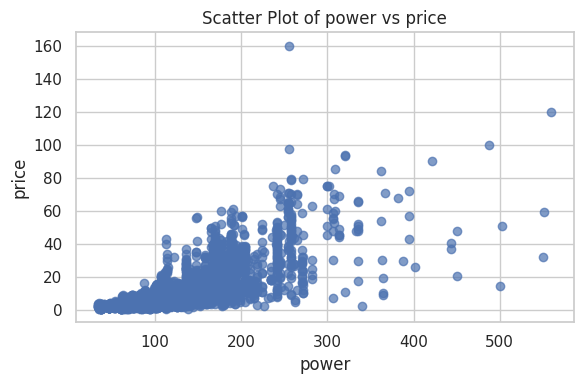

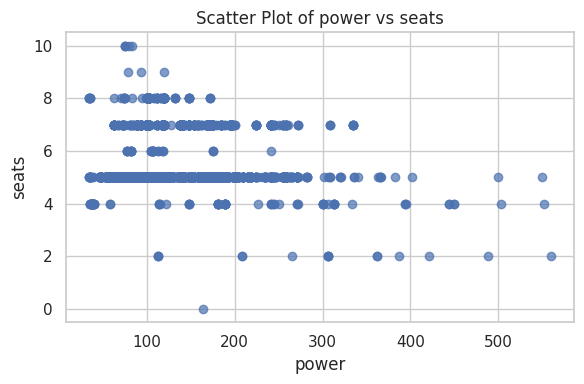

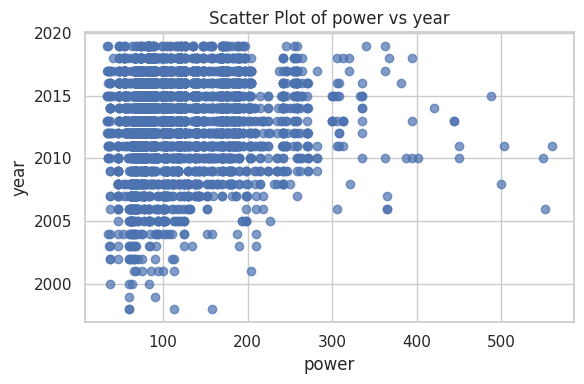

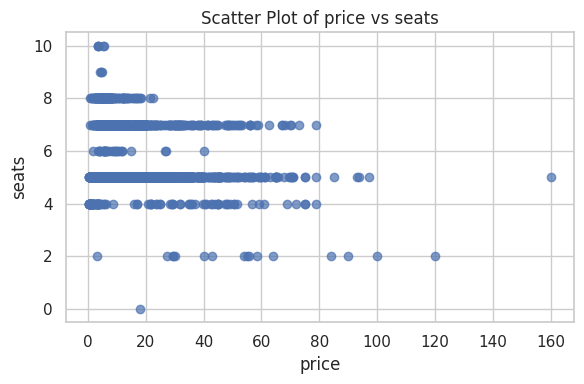

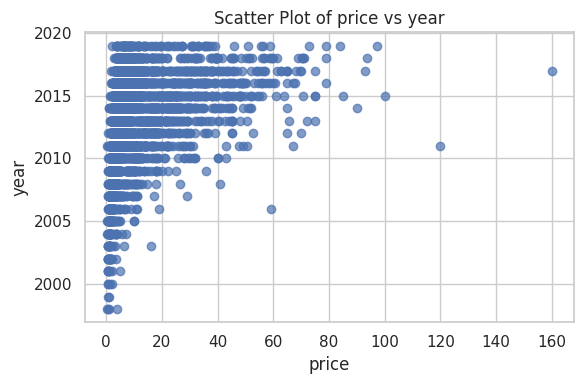

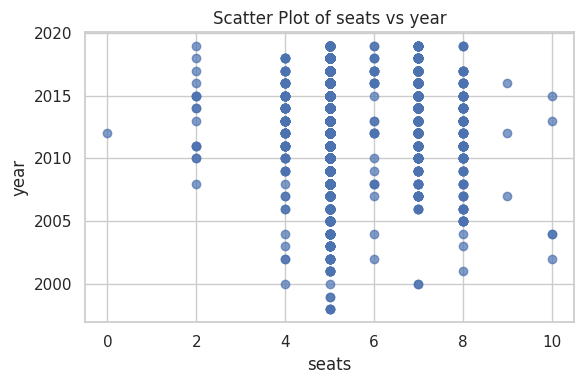

In [108]:
import matplotlib.pyplot as plt
import pandas as pd

# Assuming `df` is your dataframe with the data

# List of column pairs to plot
columns = ['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']

# Loop through each unique pair of columns
for i, col1 in enumerate(columns):
    for j, col2 in enumerate(columns):
        if i < j:  # Ensures we don’t duplicate pairs or plot same variable against itself
            plt.figure(figsize=(6, 4))
            plt.scatter(data[col1], data[col2], alpha=0.7)
            plt.xlabel(col1)
            plt.ylabel(col2)
            plt.title(f'Scatter Plot of {col1} vs {col2}')
            plt.tight_layout()
            plt.show()


**KDE Plot for Numerical Values**

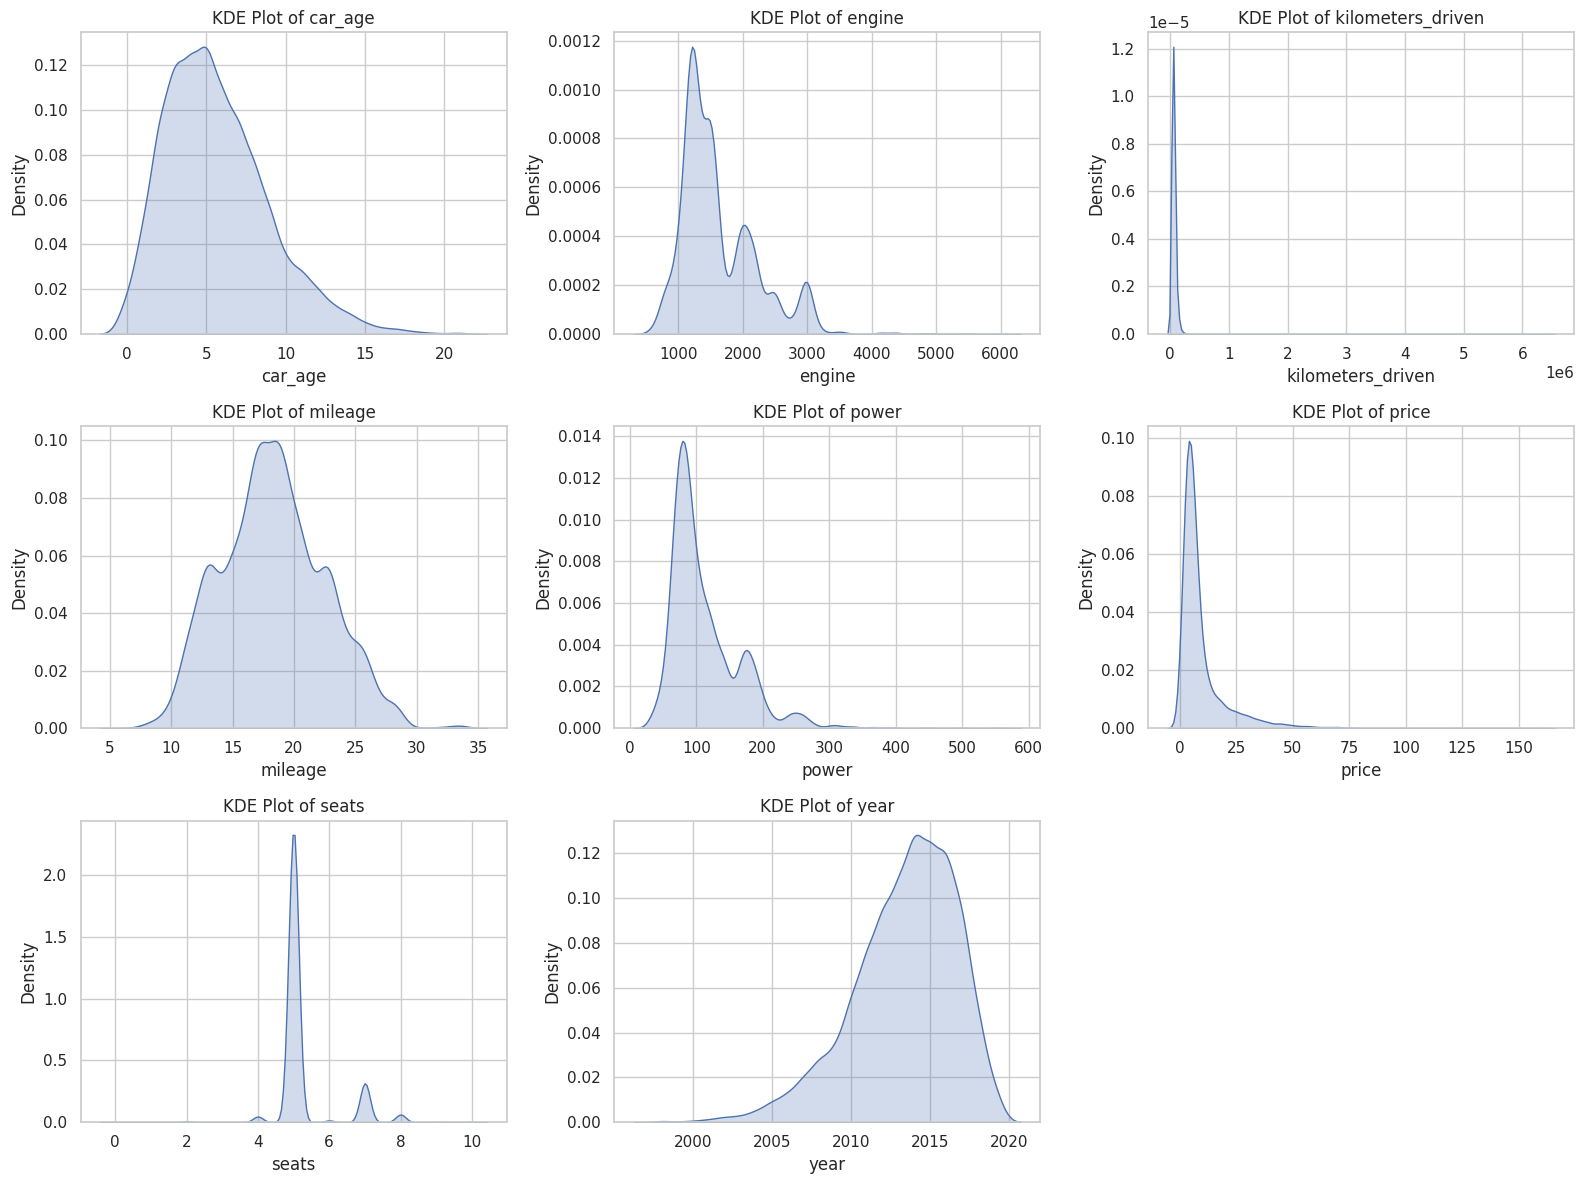

In [109]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of columns to plot
columns = ['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']

# Set up the plotting area
plt.figure(figsize=(16, 12))

# Generate KDE plots for each column
for i, col in enumerate(columns, 1):
    plt.subplot(3, 3, i)
    sns.kdeplot(data[col], shade=True)
    plt.title(f'KDE Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

**Histogram Overview**

In [110]:
def histogram_overview(data):
    """
    Histogram Overview function

    This function below generates a subplots of  `histogram plots` &
    showing the `distribution of the numerical varible input`

    * Generates subplots for each numerical variable in a three column structure.
    * The function takes the Pandas dataframe as the input
    * The function selects the numerical variables from the applied dataframe.
    * It generates a vertical `line` to indicate the `mean`, `median` and `mode` on the histogram
    * `sns.set_style` - sets the Seaborn theme
    * `subplot_nrows` - calculated number of subplot rows
    * `subplot_ncols` - configures the three column structure subplots
    * `figsize` - indicates the size of the plot
    * `sns.reset_defaults()` - resets Seaborn themes and settings to default

    """
    num_vars = data.select_dtypes(include=np.number).columns.to_list()
    plt.figure(figsize=(10, 10))
    for i in range(len(num_vars)):
        # Set seaborn theme
        sns.set_style("darkgrid")
        # Subplot no of columns
        subplot_ncols = math.ceil(np.sqrt(len(num_vars)))
        # Subplot no of rows
        subplot_nrows = subplot_ncols

        plt.subplot(subplot_nrows, subplot_ncols, i + 1)

        plt.hist(data[num_vars[i]])
        #Plot vertical line for the mean
        plt.axvline(data[num_vars[i]].mean(),
                    color='green',
                    linestyle='--',
                    label="mean")
        #Plot vertical line for the median
        plt.axvline(data[num_vars[i]].median(),
                    color='red',
                    linestyle='-',
                    label="median")
        #Plot vertical line for the mode
        plt.axvline(data[num_vars[i]].mode()[0],
                    color='black',
                    linestyle='-',
                    label="mode")
        plt.legend()
        plt.tight_layout()
        plt.title(num_vars[i], fontsize=16)
    plt.show()
    # Reset seaborn theme
    sns.reset_defaults()

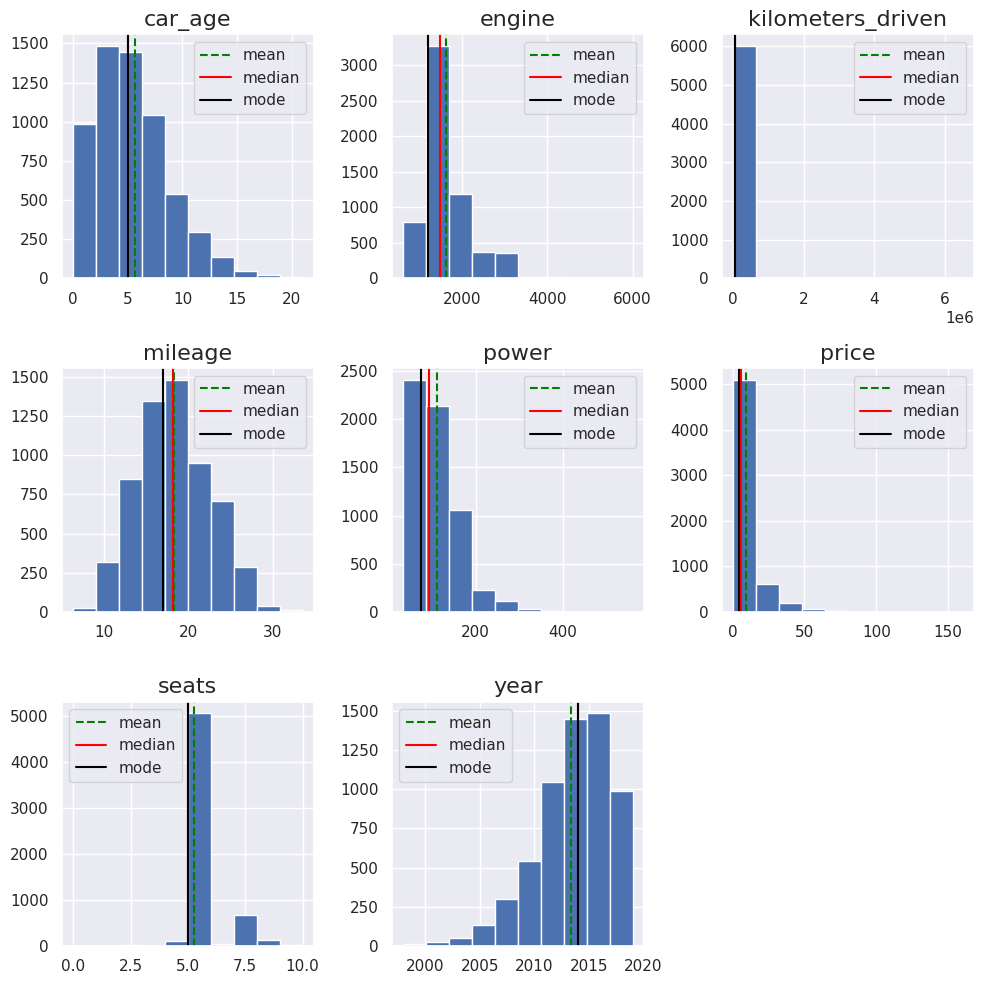

In [111]:
histogram_overview(data)

**Observation:**
* **car_age** - Right skewed as majority of the used cars less than 10 years old.
* **engine**  - Right skewed as there some cars with large engines.
* **kilometers_driven** is highly right skewed. There may be as a result of a few outliers beyond 200,000. These outliers will be dealt with later on.
* **mileage** - Somewhat normally distribited.
* **power** - Right skewed as there are a cars with large engines.
* **price** - Highly right skewed as there may a few used luxury cars for sale.
* **seats**  - There is no clear distribution as seats are ordinal numerical variables. Majority of the cars have 5 seats.
* **year** -  Left skewed as the majority of the used cars were manufactured from 2010.

**Boxplot overview**

In [112]:
def boxplot_overview(data):
    """
    This function below generates a subplots of `box plots` &
    showing the `distribution of the numerical variable input with outliers`.

    * Generates subplots for each numerical variable in a three column structure.
    * The function takes the Pandas dataframe as the input
    * The function selects the numerical variables from the applied dataframe.
    * It shows the `mean` in the boxplot.
    * `sns.set_style` - sets the Seaborn theme
    * `subplot_nrows` - calculated number of subplot rows
    * `subplot_ncols` - configures the three column structure subplots
    * `figsize` - indicates the size of the plot
    * `sns.reset_defaults()` - resets Seaborn themes and settings to default
    """

    num_vars = data.select_dtypes(include=np.number).columns.to_list()
    plt.figure(figsize=(10, 10))
    for i in range(len(num_vars)):
        # Set seaborn theme
        sns.set_style("darkgrid")
        # Subplot no of columns
        subplot_ncols = math.ceil(np.sqrt(len(num_vars)) )
        # Subplot no of rows
        subplot_nrows = math.ceil(len(num_vars) / subplot_ncols)

        plt.subplot(subplot_nrows, subplot_ncols, i + 1)
        sns.boxplot(y=data[num_vars[i]], width=0.3, showmeans=True)
        plt.tight_layout()
        plt.title(num_vars[i], fontsize=16)
    plt.show()
    # Reset seaborn theme
    sns.reset_defaults()

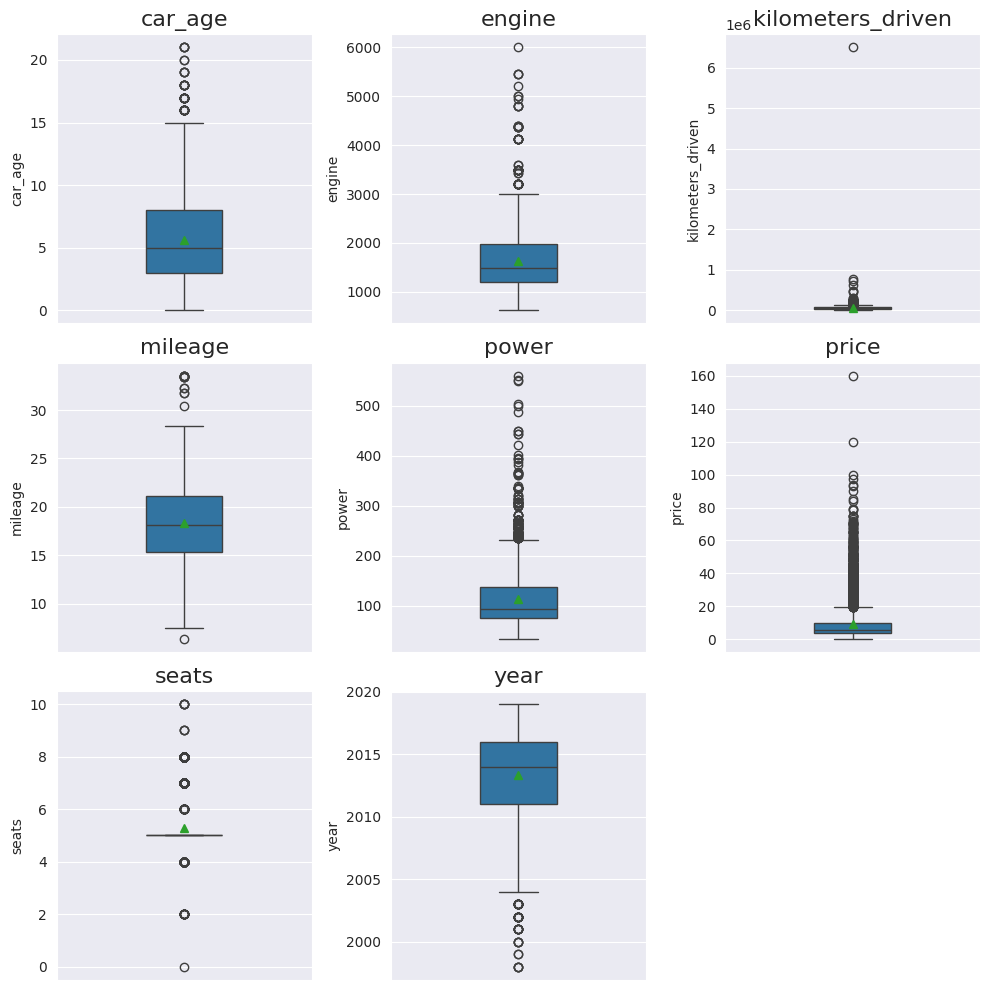

In [113]:
boxplot_overview(data)

**Observation:**
* There are significant amount of upper outliers is the **engine**,**kilometers_driven**, **power** and **price** variables.
* **kilometers_driven** - There are many outliers but there a few significantly large ones skewing the data.
* **seats**  - Since seats is discete numerical variable there are outliers around the medin.
* **year** -  There are lot of lower outliers.

---

**Outlier check function**

In [114]:
# Outlier check
def outlier_count(data):
    """
    This function checks the lower and upper
    outliers for all numerical variables.

    Outliers are found where data points exists either:
    - Greater than `1.5*IQR` above the 75th percentile
    - Less than `1.5*IQR` below the 25th percentile
    """
    numeric = data.select_dtypes(include=np.number).columns.to_list()
    for i in numeric:
        # Get name of series
        name = data[i].name
        # Calculate the IQR for all values and omit NaNs
        IQR = spy.stats.iqr(data[i], nan_policy="omit")
        # Calculate the boxplot upper fence
        upper_fence = data[i].quantile(0.75) + 1.5 * IQR
        # Calculate the boxplot lower fence
        lower_fence = data[i].quantile(0.25) - 1.5 * IQR
        # Calculate the count of outliers above upper fence
        upper_outliers = data[i][data[i] > upper_fence].count()
        # Calculate the count of outliers below lower fence
        lower_outliers = data[i][data[i] < lower_fence].count()
        # Check if there are no outliers
        if (upper_outliers == 0) & (lower_outliers == 0):
            continue
        print(
            f"The '{name}' distribution has '{lower_outliers}' lower outliers and '{upper_outliers}' upper outliers.\n"
        )

In [115]:
#Applying the Outlier check function
outlier_count(data)

The 'car_age' distribution has '0' lower outliers and '50' upper outliers.

The 'engine' distribution has '0' lower outliers and '61' upper outliers.

The 'kilometers_driven' distribution has '0' lower outliers and '202' upper outliers.

The 'mileage' distribution has '1' lower outliers and '14' upper outliers.

The 'power' distribution has '0' lower outliers and '238' upper outliers.

The 'price' distribution has '0' lower outliers and '718' upper outliers.

The 'seats' distribution has '116' lower outliers and '848' upper outliers.

The 'year' distribution has '50' lower outliers and '0' upper outliers.



**Swarm Plot**

In [116]:
df = data[['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']]
# Melt the DataFrame to have 'feature' as a column and 'price' as the y-axis
df_melted = df.melt(id_vars='price', var_name='Feature', value_name='Value')

# Create a swarm plot with 'price' on the y-axis
plt.figure(figsize=(12, 8))
sns.swarmplot(data=df_melted, x='Feature', y='price', palette='viridis', size=8)
plt.title('Swarm Plot of Price vs. Numeric Features', fontsize=16)
plt.xlabel('Numeric Features', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Adjusts layout for better fit
plt.show()

KeyboardInterrupt: 

**Strip Plot**

In [ ]:
df = data[['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']]

# Melt the DataFrame to have 'feature' as a column and 'price' as the y-axis
df_melted = df.melt(id_vars='price', var_name='Feature', value_name='Value')

# Create a strip plot with 'price' on the y-axis
plt.figure(figsize=(12, 8))
sns.stripplot(data=df_melted, x='Feature', y='price', palette='viridis', jitter=True)
plt.title('Strip Plot of Price vs. Numeric Features', fontsize=16)
plt.xlabel('Numeric Features', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Adjusts layout for better fit
plt.show()

**Violin Plot**

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

df = data[['car_age', 'engine', 'kilometers_driven', 'mileage', 'power', 'price', 'seats', 'year']]
# Melt the DataFrame to have 'feature' as a column and 'price' as the y-axis
df_melted = df.melt(id_vars='price', var_name='Feature', value_name='Value')

# Create a violin plot with 'price' on the y-axis
plt.figure(figsize=(12, 8))
sns.violinplot(data=df_melted, x='Feature', y='price', palette='viridis', inner='quartile', scale='width')
plt.title('Violin Plot of Price vs. Numeric Features', fontsize=16)
plt.xlabel('Numeric Features', fontsize=14)
plt.ylabel('Price', fontsize=14)
plt.xticks(rotation=45, fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()  # Adjusts layout for better fit
plt.show()

**Skew Summary**

In [ ]:
# Display the skew summary for the numerical variables
for var in data.select_dtypes(include=np.number).columns.to_list():
    var_skew = data[var].skew()
    if var_skew > 1:
        print(f"The '{var}' distribution is highly right skewed.\n")
    elif var_skew < -1:
        print(f"The '{var}' distribution is highly left skewed.\n")
    elif (var_skew > 0.5) & (var_skew < 1):
        print(f"The '{var}' distribution is moderately right skewed.\n")
    elif (var_skew < -0.5) & (var_skew > -1):
        print(f"The '{var}' distribution is moderately left skewed.\n")
    else:
        print(f"The '{var}' distribution is fairly symmetrical.\n")

### Correlation Analysis

Let's check to see to see if there are correlations between the numerical variables.

From above we have defined a `num_var` as a list of numerical variables.  
Let's use this list to generate a sub dataframe for correlation analysis.  
We shall use the `filter()` function as it can retrieve columns based on the column names.

In [ ]:
num_df = data.filter(num_var)
num_df.head()

Let's drop `year` column since it is a temporal varible.

In [ ]:
num_df = num_df.drop(columns='year')

**Heat Map**

In [ ]:
oh_corr = num_df.corr()

annot_kws = {"fontsize": 12}

symmetric_matrix = (oh_corr + oh_corr.T) / 2

# Create a mask for the upper half of the matrix
mask = np.triu(np.ones_like(symmetric_matrix), k=1)

plt.figure(figsize=(16, 12))
sns.heatmap(oh_corr, annot=True, fmt=".2f", mask=mask,
            cmap='coolwarm', square=True, annot_kws=annot_kws)
plt.yticks(rotation=0)
plt.show()

---

## Categorical Variables

**List of categorical variables**

In [118]:
cat_var = data.select_dtypes(exclude=np.number).columns.to_list()
print(cat_var)

['car_name', 'car_make', 'car_model', 'car_spec', 'fuel_type', 'location', 'mileage_unit', 'owner_type', 'transmission']


In [119]:
for var in cat_var:
    if any(data[var].value_counts()==0):
        data[var] = data[var].cat.remove_unused_categories()

Now let's check the number of states each categorical variable has to determine how we explore them.

In [120]:
# Check the unique values
data[cat_var].nunique().to_frame().T

,car_name,car_make,car_model,car_spec,fuel_type,location,mileage_unit,owner_type,transmission
0,213,30,209,1703,4,11,2,4,2


# Feature Scaling


**Create a clone of the dataset**

In [121]:
df1 = copy.deepcopy(data)

**Dropping unnecessary columns**

In [122]:
df1_cols = df1.columns.to_list()
drop_cols = ['car_name', 'car_make', 'car_model', 'car_spec','location', 'year']
df1.drop(columns=drop_cols, inplace=True)

**Dropping highly correlated columns**

The `engine` and `power` variables were highly positively correlated. In the context of vehicles, the bigger the engine size the more powerful is the vehicle.

Therefore the `power` variable will also be dropped.

In [123]:
df1.drop(columns='power', inplace=True)

**Scaling Mileage based on Mileage units**

To do this we shall create two separate series for the scaled value of either unit then combine both series.

In [124]:
# For "kmpl"
x = df1[df1.mileage_unit == "kmpl"].mileage
x_min = x.min()
x_max = x.max()
df1["kmpl_temp"] = x.apply(lambda x: (x - x_min / (x_max - x_min)))

# For "km/kg"
y = df1[df1.mileage_unit == "km/kg"].mileage
y_min = y.min()
y_max = y.max()
df1["kmkg_temp"] = y.apply(lambda y: (y - y_min / (y_max - y_min)))

# Combining scaled mileage
df1["mileage_scaled"] = df1["kmpl_temp"].combine_first(df1["kmkg_temp"])

# Drop columns "kmpl_temp", "kmkg_temp", "mileage_unit" and "mileage"
df1.drop(["kmpl_temp", "kmkg_temp", "mileage_unit",
         "mileage"], axis=1, inplace=True)

**Missing Value Check**

In [125]:
missing_val_chk(df1)

There are NO missing values in the dataset


---

Now let consider dealing with the outliers.

Lets **log transform to the numerical variables**.

Note the `seats` and `car_age` are ordinal variables which we shall not do any outlier corrections

In [126]:
# Column to Log transform
log_cols = ["engine", "kilometers_driven", "price",'mileage_scaled']

for col in log_cols:
    df1[col] = np.log(df1[col])

In [127]:
# Check the boxplot overview to see if any outliers still exist
boxplot_overview(df1)

KeyboardInterrupt: 

There is still outliers in the log transformed data but lets continue with the evaluation.

## Outlier Treatment

Now let consider dealing with the outliers.

There are different methods to deal with outliers but lets us start with **Data capping/Winsorizing**

Note the `seats` and `car_age` are ordinal variables which we shall not do any outlier corrections

Outlier are values that exist beyond the upper and lower whiskers of the boxplot.

So lets clip outliers to their respective upper and lower whisker.

**Clipping lower and upper numerical outliers to lower and upper whiskers respectively**

In [128]:
# List of numeric variables
numeric = df1.select_dtypes(include=np.number).columns.to_list()
numeric.remove('seats')
numeric.remove('car_age')

In [129]:
for var in numeric:
    Q1 = df1[var].quantile(0.25)  # 25th quantile
    Q3 = df1[var].quantile(0.75)  # 75th quantile
    IQR = Q3-Q1
    Lower_Whisker = Q1 - 1.5*IQR
    Upper_Whisker = Q3 + 1.5*IQR
    df1[var] = np.clip(df1[var], Lower_Whisker, Upper_Whisker)

In [ ]:
# Check the boxplot overview to see if any outliers still exist
boxplot_overview(df1)

There are no more outlier for continuous variables

**Encoding Categorical Variables**

In [130]:
# Get list of categorical values for onehot encoding
vars_req_encoding = df1.select_dtypes(exclude=np.number).columns.to_list()
vars_req_encoding

['fuel_type', 'owner_type', 'transmission']

**One hot encoding**

In [131]:
df1 = pd.get_dummies(df1, columns = vars_req_encoding, drop_first=True, dtype=float)
df1.head()

,car_age,engine,kilometers_driven,price,seats,mileage_scaled,fuel_type_Diesel,fuel_type_LPG,fuel_type_Petrol,owner_type_Fourth & Above,owner_type_Second,owner_type_Third,transmission_Manual
0,16,7.305860,11.289782,0.300105,5.0,2.526456,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,5,7.584773,11.280628,2.803360,5.0,3.000177,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,7.584773,9.998798,3.113515,5.0,3.000177,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,7.584773,9.903638,2.957511,5.0,3.000177,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,3,7.584773,10.571317,2.939162,5.0,3.000177,1.0,0.0,0.0,0.0,0.0,0.0,0.0


---

In [132]:
# Separating Independent and Dependent variables**
# Independant variables
X = df1.drop(['price'], axis=1)
# Dependent variable
y = df1[['price']]

In [133]:
from sklearn.model_selection import train_test_split

# Assuming X is your feature set and y is your target variable
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% for testing
    random_state=1     # Ensure reproducibility
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (4812, 12)
Testing set shape: (1204, 12)


In [134]:
print("Number of rows in train data =", X_train.shape[0])
print("Number of rows in test data =", X_test.shape[0])

Number of rows in train data = 4812
Number of rows in test data = 1204


# **Default KNN**

In [136]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [137]:
# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [143]:
# Apply KNN with default hyperparameters
knn_default = KNeighborsRegressor()
knn_default.fit(X_train, y_train)
y_pred_knn_default = knn_default.predict(X_test)

In [141]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [144]:
# Metrics for KNN (default)
print("KNN (Default):")
print("MAE:", mean_absolute_error(y_test, y_pred_knn_default))
print("MSE:", mean_squared_error(y_test, y_pred_knn_default))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn_default)))
print("R²:", r2_score(y_test, y_pred_knn_default))

KNN (Default):
MAE: 0.22948274318796957
MSE: 0.10078984726636152
RMSE: 0.3174741678725397
R²: 0.8623398831294498


In [145]:
# Apply Stacking with default hyperparameters
base_models = [('knn', KNeighborsRegressor()), ('lr', LinearRegression())]
stack_default = StackingRegressor(estimators=base_models, final_estimator=LinearRegression())
stack_default.fit(X_train, y_train)
y_pred_stack_default = stack_default.predict(X_test)

In [146]:
# Metrics for Stacking (default)
print("\nStacking (Default):")
print("MAE:", mean_absolute_error(y_test, y_pred_stack_default))
print("MSE:", mean_squared_error(y_test, y_pred_stack_default))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_stack_default)))
print("R²:", r2_score(y_test, y_pred_stack_default))


Stacking (Default):
MAE: 0.2255813499936549
MSE: 0.09124821039326221
RMSE: 0.30207318714719156
R²: 0.8753719779555879


# **Optimize KNN**

In [147]:
# Optimize KNN hyperparameters
param_grid_knn = {'n_neighbors': [3, 5, 7, 9, 11], 'weights': ['uniform', 'distance']}
grid_knn = GridSearchCV(KNeighborsRegressor(), param_grid_knn, cv=5, scoring='neg_mean_squared_error')
grid_knn.fit(X_train, y_train)
best_knn = grid_knn.best_estimator_
y_pred_knn_optimized = best_knn.predict(X_test)

In [148]:
# Metrics for KNN (optimized)
print("\nKNN (Optimized):")
print("MAE:", mean_absolute_error(y_test, y_pred_knn_optimized))
print("MSE:", mean_squared_error(y_test, y_pred_knn_optimized))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn_optimized)))
print("R²:", r2_score(y_test, y_pred_knn_optimized))


KNN (Optimized):
MAE: 0.22318962000875048
MSE: 0.09502226805226703
RMSE: 0.30825682158269757
R²: 0.8702173196987716


In [149]:
# Optimize Stacking hyperparameters
param_grid_stack = {
    'final_estimator__fit_intercept': [True, False],
    'knn__n_neighbors': [3, 5, 7],
    'knn__weights': ['uniform', 'distance']
}

In [150]:
grid_stack = GridSearchCV(
    StackingRegressor(estimators=base_models, final_estimator=LinearRegression()),
    param_grid_stack,
    cv=5,
    scoring='neg_mean_squared_error'
)

In [151]:
grid_stack.fit(X_train, y_train)
best_stack = grid_stack.best_estimator_
y_pred_stack_optimized = best_stack.predict(X_test)

In [152]:
# Metrics for Stacking (optimized)
print("\nStacking (Optimized):")
print("MAE:", mean_absolute_error(y_test, y_pred_stack_optimized))
print("MSE:", mean_squared_error(y_test, y_pred_stack_optimized))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_stack_optimized)))
print("R²:", r2_score(y_test, y_pred_stack_optimized))


Stacking (Optimized):
MAE: 0.22062001415200097
MSE: 0.08718996976899776
RMSE: 0.295279477392178
R²: 0.880914777094361


In [153]:
print("Best KNN Hyperparameters:", grid_knn.best_params_)

Best KNN Hyperparameters: {'n_neighbors': 5, 'weights': 'distance'}


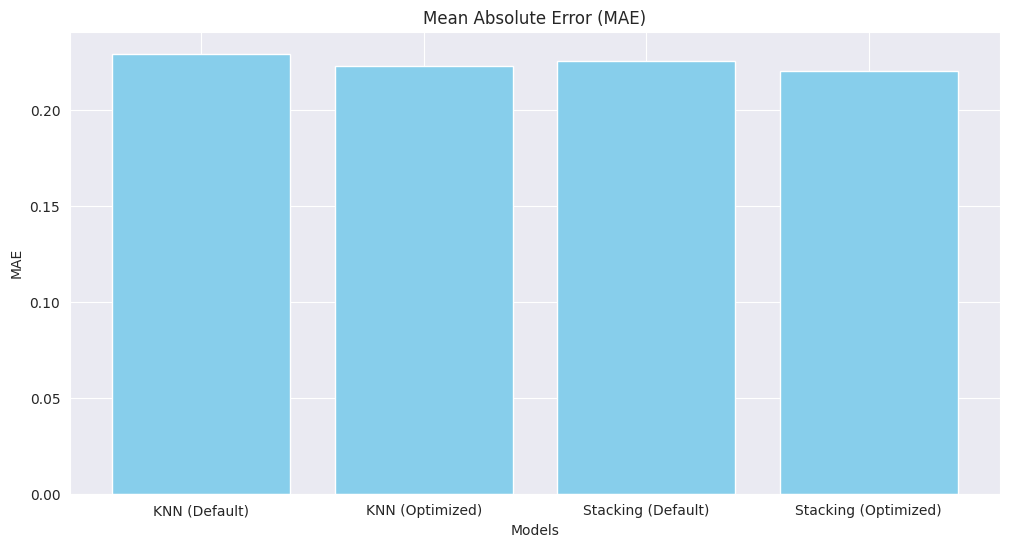

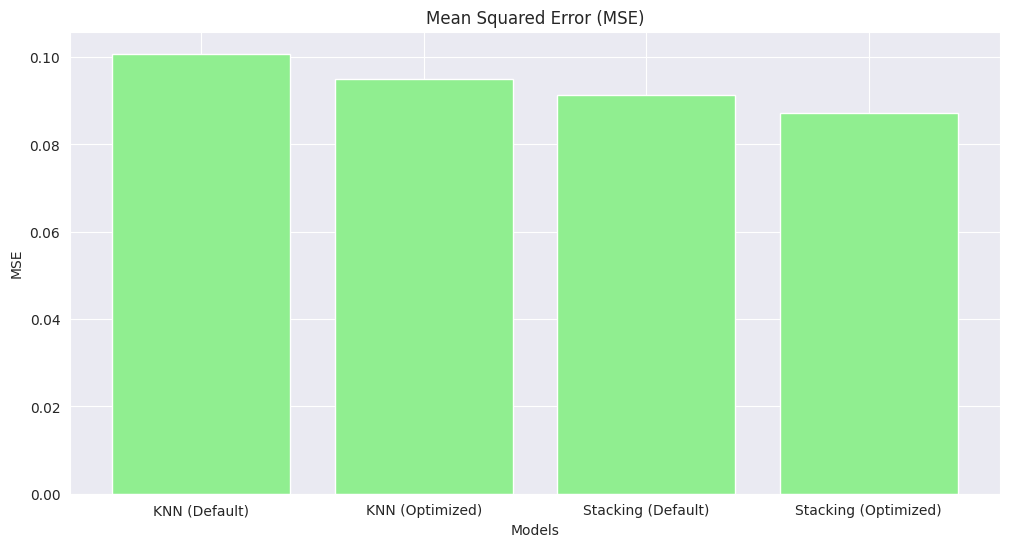

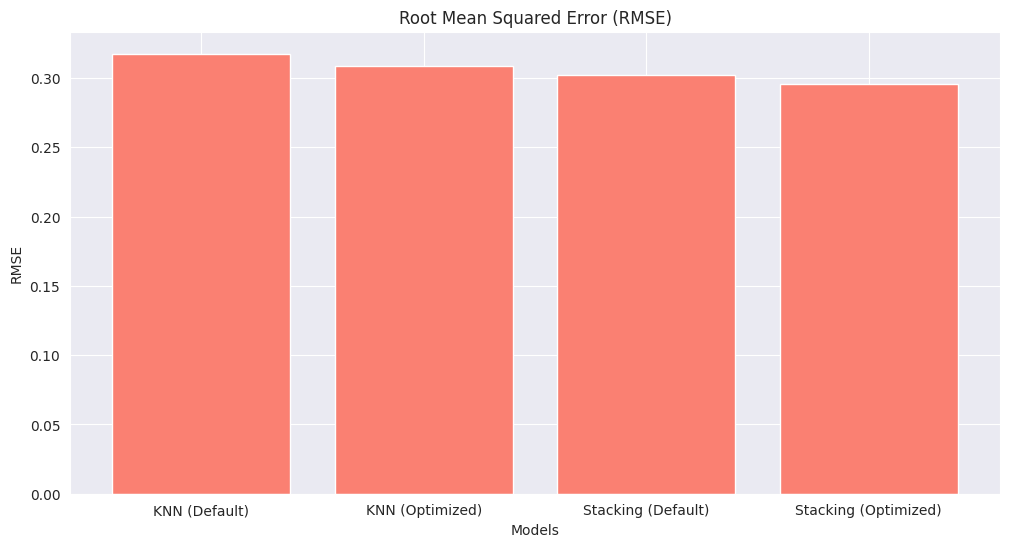

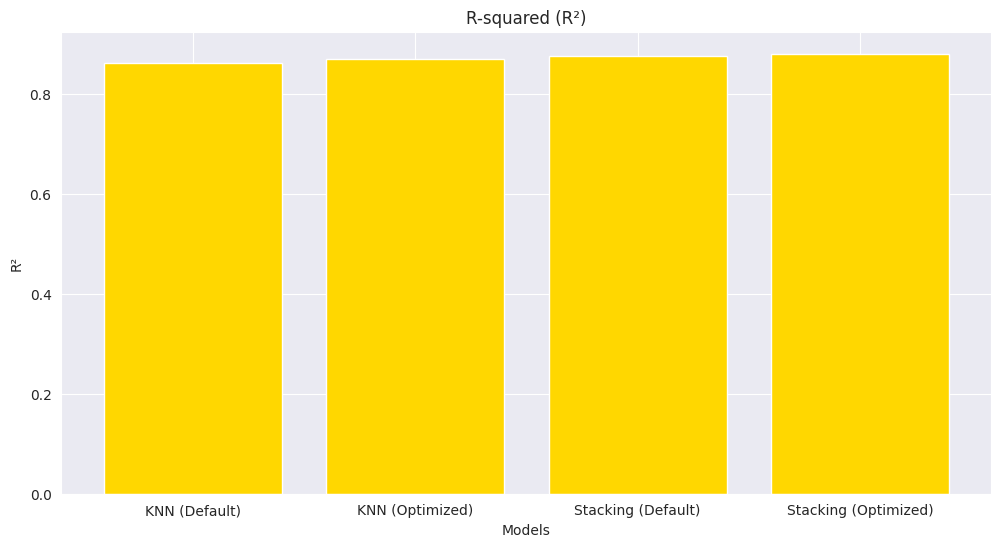

In [155]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate the evaluation metrics for each model
mae_knn_default = mean_absolute_error(y_test, y_pred_knn_default)
mae_knn_optimized = mean_absolute_error(y_test, y_pred_knn_optimized)
mae_stack_default = mean_absolute_error(y_test, y_pred_stack_default)
mae_stack_optimized = mean_absolute_error(y_test, y_pred_stack_optimized)

mse_knn_default = mean_squared_error(y_test, y_pred_knn_default)
mse_knn_optimized = mean_squared_error(y_test, y_pred_knn_optimized)
mse_stack_default = mean_squared_error(y_test, y_pred_stack_default)
mse_stack_optimized = mean_squared_error(y_test, y_pred_stack_optimized)

rmse_knn_default = np.sqrt(mse_knn_default)
rmse_knn_optimized = np.sqrt(mse_knn_optimized)
rmse_stack_default = np.sqrt(mse_stack_default)
rmse_stack_optimized = np.sqrt(mse_stack_optimized)

r2_knn_default = r2_score(y_test, y_pred_knn_default)
r2_knn_optimized = r2_score(y_test, y_pred_knn_optimized)
r2_stack_default = r2_score(y_test, y_pred_stack_default)
r2_stack_optimized = r2_score(y_test, y_pred_stack_optimized)

# Data for plotting (example data)
models = ['KNN (Default)', 'KNN (Optimized)', 'Stacking (Default)', 'Stacking (Optimized)']
mae_values = [mae_knn_default, mae_knn_optimized, mae_stack_default, mae_stack_optimized]
mse_values = [mse_knn_default, mse_knn_optimized, mse_stack_default, mse_stack_optimized]
rmse_values = [rmse_knn_default, rmse_knn_optimized, rmse_stack_default, rmse_stack_optimized]
r2_values = [r2_knn_default, r2_knn_optimized, r2_stack_default, r2_stack_optimized]

# Plot MAE
plt.figure(figsize=(12, 6))
plt.bar(models, mae_values, color='skyblue')
plt.title('Mean Absolute Error (MAE)')
plt.ylabel('MAE')
plt.xlabel('Models')
plt.show()

# Plot MSE
plt.figure(figsize=(12, 6))
plt.bar(models, mse_values, color='lightgreen')
plt.title('Mean Squared Error (MSE)')
plt.ylabel('MSE')
plt.xlabel('Models')
plt.show()

# Plot RMSE
plt.figure(figsize=(12, 6))
plt.bar(models, rmse_values, color='salmon')
plt.title('Root Mean Squared Error (RMSE)')
plt.ylabel('RMSE')
plt.xlabel('Models')
plt.show()

# Plot R²
plt.figure(figsize=(12, 6))
plt.bar(models, r2_values, color='gold')
plt.title('R-squared (R²)')
plt.ylabel('R²')
plt.xlabel('Models')
plt.show()
